In [67]:
import numpy as np 
import pandas as pd 
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
import rioxarray as rxr
import pickle
from astropy.time import Time

### Load the file output by the process_icesat2.ipynb

In [3]:
atl06sr_gdf = pickle.load(open('../data/temp/gdf_1m_sierras_concat_sorted_processed.pkl', 'rb'))

In [4]:
sierras = gpd.read_file('../data/misc/sierras_polygon_gmba.geojson')

In [5]:
reanalysis_2021 = xr.open_dataset('../data/reanalysis/reanalysis_sierras_processed_2021.nc')

### Compare snow-off ICESat-2 to sampled 1m 3DEP:

In [ ]:
atl06sr_gdf.columns

Index(['pflags', 'h_mean', 'n_fit_photons', 'region', 'w_surface_window_final',
       'dh_fit_dx', 'cycle', 'segment_id', 'h_sigma', 'rms_misfit', 'spot',
       'y_atc', 'x_atc', 'gt', 'rgt', 'geometry', '3dep.flags', '3dep.file_id',
       '3dep.time', '3dep.value', '3dep', 'time_acq', 'snow_depth', 'acqdate',
       'is2_1m_dif', 'doy', 'decyear', 'dowy', 'reanalysis_fsca',
       'reanalysis_sd', 'snowoff_offset'],
      dtype='object')

In [ ]:
atl06sr_gdf['snow_depth'] = atl06sr_gdf['h_mean'] - atl06sr_gdf['3dep']

<Axes: >

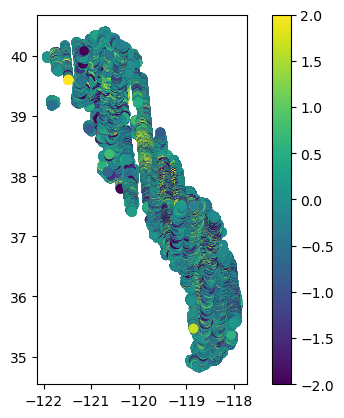

In [ ]:
atl06sr_gdf.plot(column='snow_depth', legend=True, vmin=-2, vmax=2)

In [ ]:
atl06sr_gdf['reanalysis_offset'] = atl06sr_gdf['snow_depth'] - atl06sr_gdf['reanalysis_sd']

<Axes: >

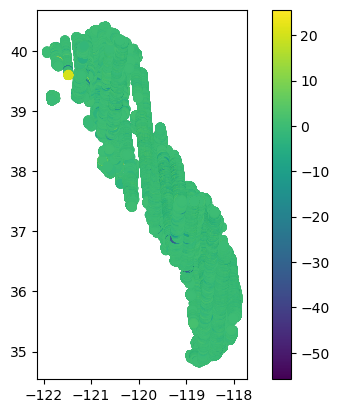

In [ ]:
atl06sr_gdf.plot(column='snow_depth', legend=True)

In [ ]:
np.sqrt(len(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_fsca']==0)]))

np.float64(719.4782832024883)

Text(0.5, 1.0, 'snow-off median difference from 3dep: -0.12')

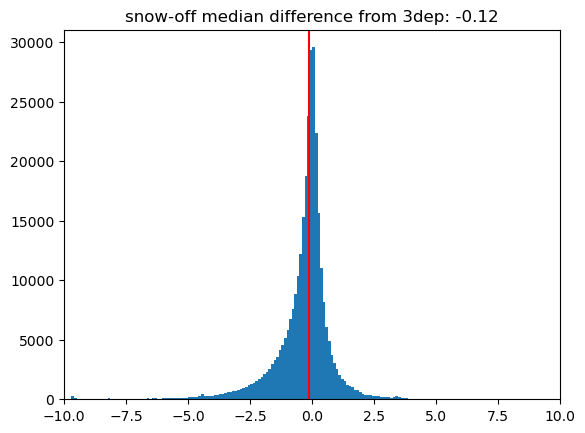

In [ ]:
fig, ax = plt.subplots()

ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_fsca']==0), 'snow_depth'], bins=719 )
ax.set_xlim(-10,10)
ax.axvline(x=np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_fsca']==0), 'snow_depth']), c='red')
ax.set_title(f'snow-off median difference from 3dep: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_fsca']==0), 'snow_depth']):.2f}')

In [ ]:
np.sqrt(len(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_fsca']>0.1)]))

np.float64(498.8566928487579)

Text(0.5, 1.0, 'snow-on median difference from 3dep: 0.03')

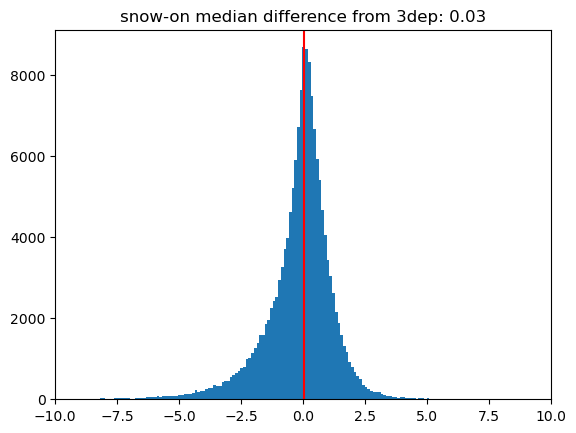

In [ ]:
fig, ax = plt.subplots()

subset = atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_fsca']>0.1), 'snow_depth']
ax.hist(subset, bins=500)
ax.set_xlim(-10,10)
ax.axvline(x=np.nanmedian(subset), c='red')
ax.set_title(f'snow-on median difference from 3dep: {np.nanmedian(subset):.2f}')

Text(0.5, 1.0, 'snow-on median difference from 3dep: 0.14')

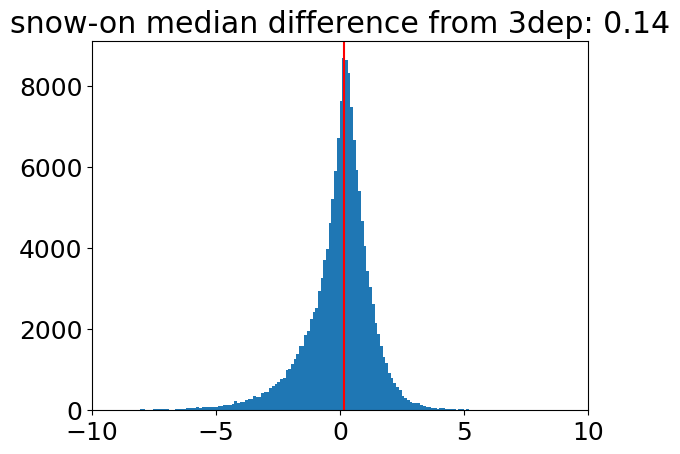

In [62]:
fig, ax = plt.subplots()

subset = atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_fsca']>0.1), 'snow_depth_plus']
ax.hist(subset, bins=500)
ax.set_xlim(-10,10)
ax.axvline(x=np.nanmedian(subset), c='red')
ax.set_title(f'snow-on median difference from 3dep: {np.nanmedian(subset):.2f}')

Text(0.5, 1.0, 'Snow-on offset from reanalysis snow depth: -0.29')

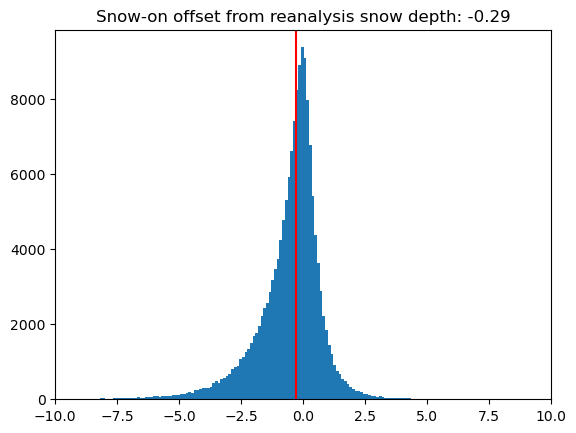

In [ ]:
fig, ax = plt.subplots()

subset = atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_fsca']>0.1), 'reanalysis_offset']
ax.hist(subset, bins=500)
ax.set_xlim(-10,10)
ax.axvline(x=np.nanmedian(subset), c='red')
ax.set_title(f'Snow-on offset from reanalysis snow depth: {np.nanmedian(subset):.2f}')

Text(0.5, 1.0, 'snow-on median difference from 3dep at high elevation: 0.22')

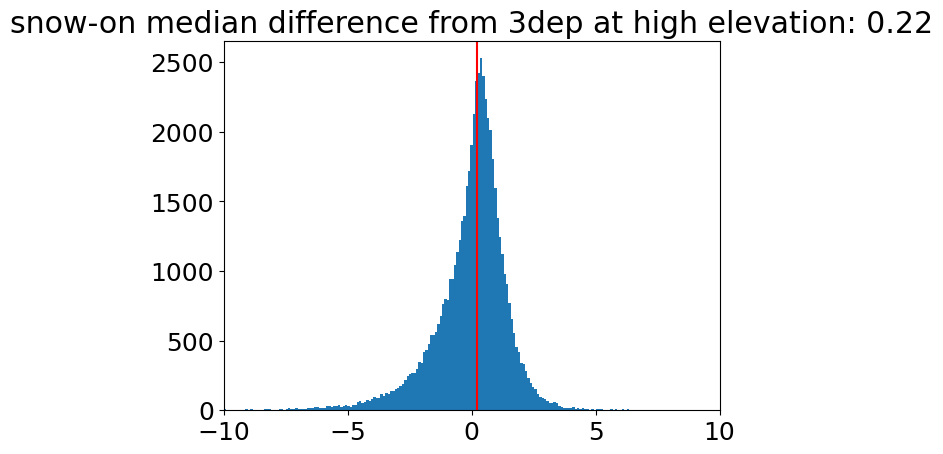

In [64]:
fig, ax = plt.subplots()

subset = atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_fsca']>0.5) & (atl06sr_gdf['3dep']>2500) & (atl06sr_gdf['3dep']<3500), 'snow_depth_plus']
ax.hist(subset, bins=500)
ax.set_xlim(-10,10)
ax.axvline(x=np.nanmedian(subset), c='red')
ax.set_title(f'snow-on median difference from 3dep at high elevation: {np.nanmedian(subset):.2f}')

Text(0.5, 1.0, 'snow-on median difference from reanalysis at high elevation: -0.40')

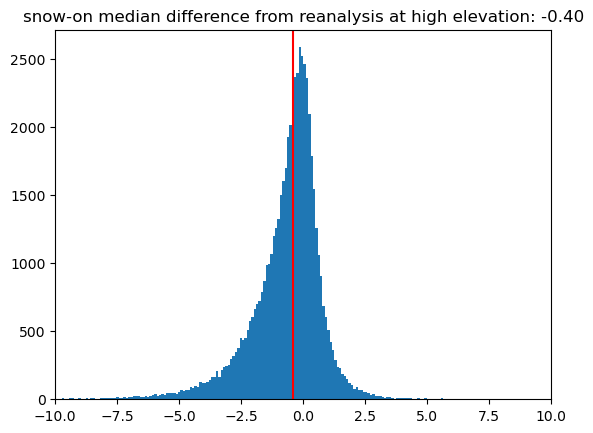

In [ ]:
fig, ax = plt.subplots()

subset = atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_fsca']>0.5) & (atl06sr_gdf['3dep']>2500) & (atl06sr_gdf['reanalysis_fsca']>0.1) & (atl06sr_gdf['3dep']<3500), 'reanalysis_offset']
ax.hist(subset, bins=500)
ax.set_xlim(-10,10)
ax.axvline(x=np.nanmedian(subset), c='red')
ax.set_title(f'snow-on median difference from reanalysis at high elevation: {np.nanmedian(subset):.2f}')

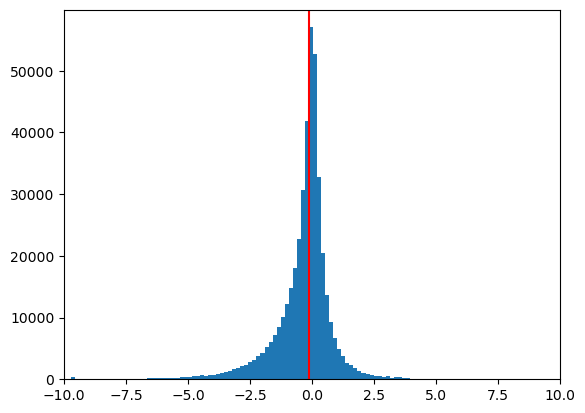

In [ ]:
fig, ax = plt.subplots()

subset = atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_fsca']<0.5), 'snow_depth']
ax.hist(subset, bins=500)
ax.set_xlim(-10,10)
ax.axvline(x=np.nanmedian(subset), c='red')

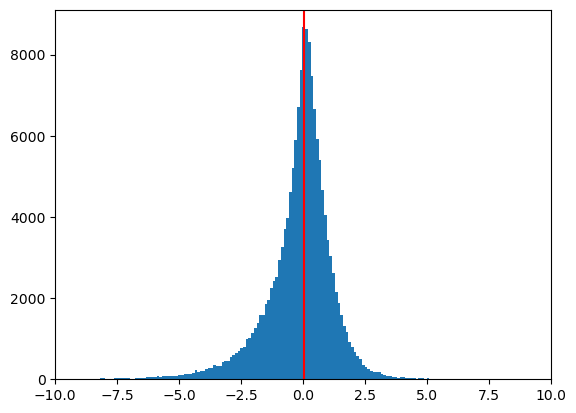

In [ ]:
fig, ax = plt.subplots()

subset = atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_fsca']>0.1), 'snow_depth']
ax.hist(subset, bins=500)
ax.set_xlim(-10,10)
ax.axvline(x=np.nanmedian(subset), c='red')

(0.0, 10000.0)

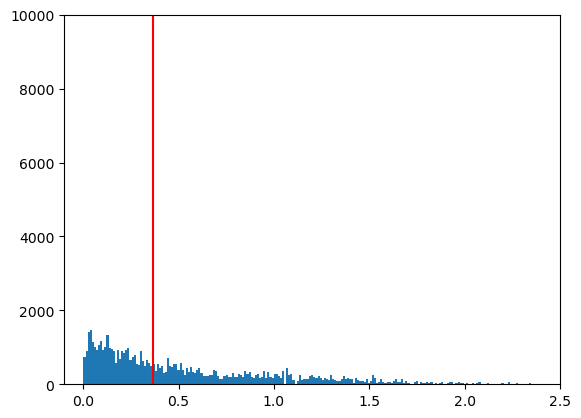

In [ ]:
fig, ax = plt.subplots()

subset = atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_fsca']>0.5) & (atl06sr_gdf['3dep']>2500) & (atl06sr_gdf['reanalysis_fsca']>0.1) & (atl06sr_gdf['3dep']<3500), 'reanalysis_sd']
ax.hist(subset, bins=int(np.sqrt(len(subset))))
ax.set_xlim(-10,10)
ax.axvline(x=np.nanmedian(subset), c='red')
plt.xlim(-0.1, 2.5)
plt.ylim(0,10000)

(0.0, 10000.0)

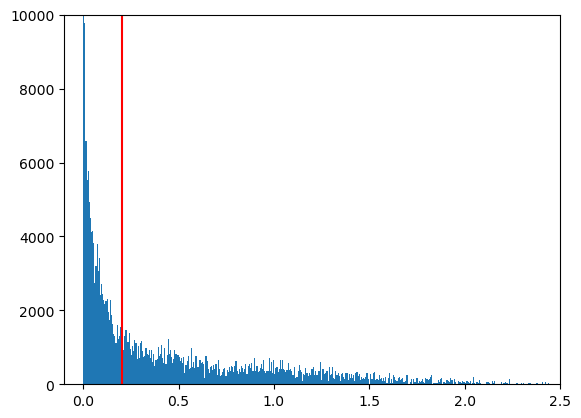

In [ ]:
fig, ax = plt.subplots()

subset = atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_fsca']>0.1), 'reanalysis_sd']
ax.hist(subset, bins=int(np.sqrt(len(subset))))
ax.set_xlim(-10,10)
ax.axvline(x=np.nanmedian(subset), c='red')
plt.xlim(-0.1, 2.5)
plt.ylim(0,10000)

(0.0, 10000.0)

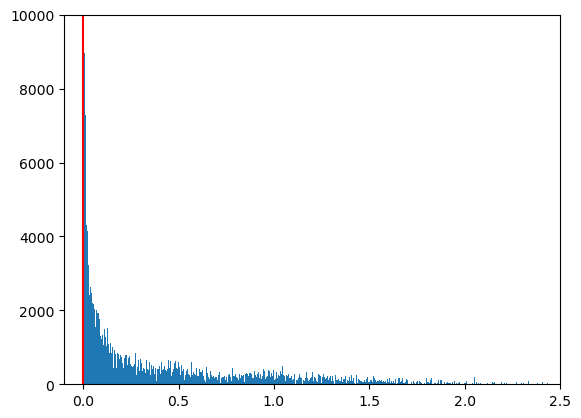

In [ ]:
fig, ax = plt.subplots()

subset = atl06sr_gdf['reanalysis_sd']
ax.hist(subset, bins=int(np.sqrt(len(subset))))
ax.set_xlim(-10,10)
ax.axvline(x=np.nanmedian(subset), c='red')
plt.xlim(-0.1, 2.5)
plt.ylim(0,10000)

In [ ]:
atl06sr_gdf['reanalysis_offset'].describe()

count    544024.000000
mean         -0.517016
std           2.180305
min         -55.856241
25%          -0.811641
50%          -0.162260
75%           0.183828
max          25.619407
Name: reanalysis_offset, dtype: float64

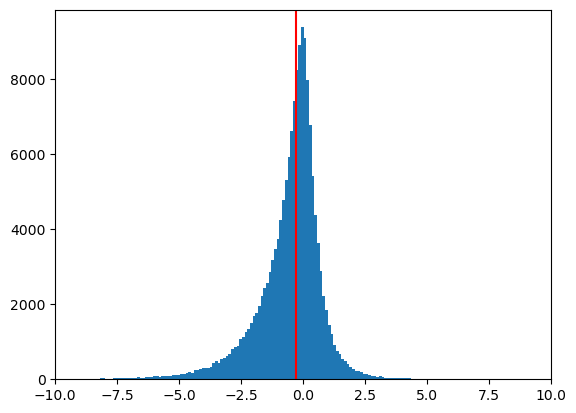

In [ ]:
fig, ax = plt.subplots()

ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_fsca']>0.1), 'reanalysis_offset'], bins=500)
ax.set_xlim(-10,10)
ax.axvline(x=np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_fsca']>0.1), 'reanalysis_offset']), c='red')

In [ ]:
np.nanmin(atl06sr_gdf['3dep'])

np.float64(0.6367362927588118)

In [ ]:
np.nanmax(atl06sr_gdf['3dep'])

np.float64(4225.550867968473)

In [ ]:
np.sqrt(len(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_fsca']>0.1) & (atl06sr_gdf['3dep']>3000), 'snow_depth']))

np.float64(187.91753510516256)

In [ ]:
subset

,pflags,h_mean,n_fit_photons,region,w_surface_window_final,dh_fit_dx,cycle,segment_id,h_sigma,rms_misfit,...,snow_depth,acqdate,is2_1m_dif,doy,decyear,dowy,reanalysis_fsca,reanalysis_sd,snowoff_offset,reanalysis_offset
time,,,,,,,,,,,,,,,,,,,,,
2021-06-02 13:39:48.914078720,0,2724.396479,10,6,3.511048,0.135583,11,796986,0.133119,0.137918,...,-0.037014,2021-06-02,-0.037014,153,2021.417998,245,0.1090,0.0320,NaN,-0.069014
2021-06-02 13:39:48.911247360,0,2721.678492,10,6,3.511048,0.135583,11,796985,0.075095,0.137918,...,-0.005201,2021-06-02,-0.005201,153,2021.417998,245,0.1090,0.0320,NaN,-0.037201
2021-06-02 13:39:48.899887872,0,2704.984492,29,6,3.000000,0.025941,11,796981,0.095927,0.242274,...,-1.337230,2021-06-02,-1.337230,153,2021.417998,245,0.1090,0.0320,NaN,-1.369230
2021-06-02 13:39:48.897047296,0,2704.567323,29,6,3.000000,0.010344,11,796980,0.052516,0.231982,...,-0.132048,2021-06-02,-0.132048,153,2021.417998,245,0.1090,0.0320,NaN,-0.164048
2021-06-02 13:39:48.894219520,0,2704.019605,11,6,3.000000,0.057611,11,796979,0.077389,0.230893,...,-0.775677,2021-06-02,-0.775677,153,2021.417998,245,0.1090,0.0320,NaN,-0.807677
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-11-09 11:16:40.493037056,0,2535.452647,170,2,8.798659,0.344211,9,208148,0.029543,0.385057,...,-0.625068,2020-11-09,-0.625068,314,2020.856475,41,0.9842,0.0248,NaN,-0.649868
2020-11-09 11:16:40.490212352,0,2528.405977,159,2,9.181166,0.359246,9,208147,0.025088,0.316351,...,-0.299452,2020-11-09,-0.299452,314,2020.856475,41,0.9842,0.0248,NaN,-0.324252
2020-11-09 11:16:40.487387904,0,2521.231988,136,2,9.223231,0.360899,9,208146,0.036472,0.424984,...,-0.260825,2020-11-09,-0.260825,314,2020.856475,41,0.9842,0.0248,NaN,-0.285625


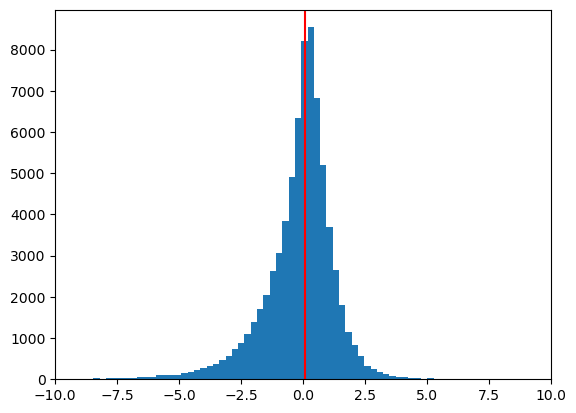

In [ ]:
fig, ax = plt.subplots()
subset = atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_fsca']>0.1) & (atl06sr_gdf['3dep']>2500) & (atl06sr_gdf['reanalysis_fsca']>0.1) & (atl06sr_gdf['3dep']<3500), 'snow_depth']
ax.hist(subset, bins=188)
ax.set_xlim(-10,10)
ax.axvline(x=np.nanmedian(subset), c='red')

<Axes: >

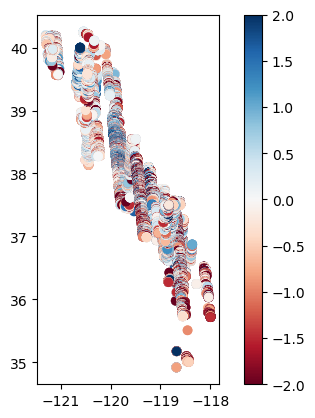

In [ ]:
atl06sr_gdf[atl06sr_gdf['reanalysis_fsca']>0.1].plot(column='snow_depth', legend=True, vmin=-2, vmax=2, cmap='RdBu')

<Axes: >

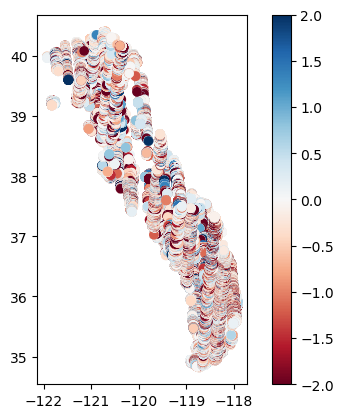

In [ ]:
atl06sr_gdf[atl06sr_gdf['reanalysis_fsca']==0].plot(column='snow_depth', legend=True, vmin=-2, vmax=2, cmap='RdBu')

In [ ]:
acq_dates = atl06sr_gdf['acqdate'].unique().tolist()

In [ ]:
acq_dates

[datetime.date(2021, 10, 12),
 datetime.date(2021, 10, 9),
 datetime.date(2021, 10, 8),
 datetime.date(2021, 10, 5),
 datetime.date(2021, 10, 4),
 datetime.date(2021, 9, 30),
 datetime.date(2021, 9, 26),
 datetime.date(2021, 9, 18),
 datetime.date(2021, 9, 14),
 datetime.date(2021, 9, 13),
 datetime.date(2021, 9, 6),
 datetime.date(2021, 9, 5),
 datetime.date(2021, 9, 2),
 datetime.date(2021, 9, 1),
 datetime.date(2021, 8, 28),
 datetime.date(2021, 8, 15),
 datetime.date(2021, 8, 12),
 datetime.date(2021, 8, 11),
 datetime.date(2021, 8, 8),
 datetime.date(2021, 8, 4),
 datetime.date(2021, 8, 3),
 datetime.date(2021, 7, 14),
 datetime.date(2021, 7, 10),
 datetime.date(2021, 7, 9),
 datetime.date(2021, 7, 6),
 datetime.date(2021, 7, 5),
 datetime.date(2021, 7, 2),
 datetime.date(2021, 6, 27),
 datetime.date(2021, 6, 8),
 datetime.date(2021, 6, 6),
 datetime.date(2021, 6, 2),
 datetime.date(2021, 5, 29),
 datetime.date(2021, 5, 12),
 datetime.date(2021, 5, 6),
 datetime.date(2021, 5, 4),


<Axes: >

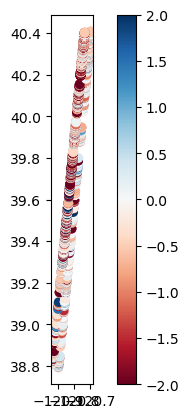

In [ ]:
atl06sr_gdf[atl06sr_gdf['acqdate']==acq_dates[0]].plot(column='snow_depth', legend=True, vmin=-2, vmax=2, cmap='RdBu')

In [ ]:
acq_dates[42]

datetime.date(2021, 3, 28)

<Axes: >

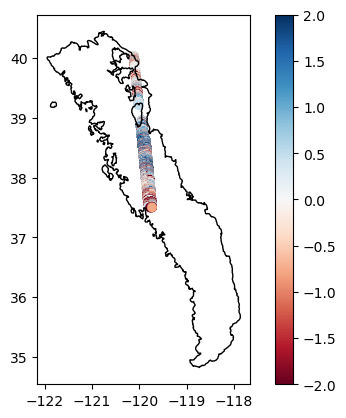

In [ ]:
fig, ax = plt.subplots()

atl06sr_gdf[atl06sr_gdf['acqdate']==acq_dates[44]].plot(ax=ax, column='snow_depth', legend=True, vmin=-2, vmax=2, cmap='RdBu')
sierras.plot(ax=ax, facecolor='none', edgecolor='k')

<Axes: >

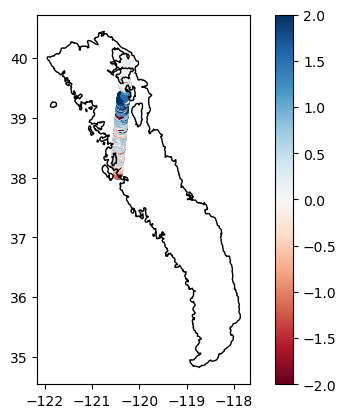

In [ ]:
fig, ax = plt.subplots()

atl06sr_gdf[atl06sr_gdf['acqdate']==acq_dates[45]].plot(ax=ax, column='snow_depth', legend=True, vmin=-2, vmax=2, cmap='RdBu')
sierras.plot(ax=ax, facecolor='none', edgecolor='k')

In [ ]:
acq_dates[40]

datetime.date(2021, 4, 7)

In [ ]:
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==acq_dates[40])]['dowy'].unique()[0]

np.int32(189)

(36.0, 38.0)

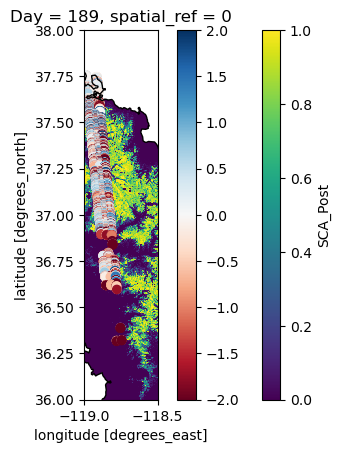

In [ ]:
fig, ax = plt.subplots()
reanalysis_2021.SCA_Post[atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==acq_dates[40])]['dowy'].unique()[0]].plot(ax=ax)
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==acq_dates[40]) & (atl06sr_gdf['reanalysis_fsca']>0.1)].plot(ax=ax, column='snow_depth', legend=True, vmin=-2, vmax=2, cmap='RdBu')
sierras.plot(ax=ax, facecolor='none', edgecolor='k')
plt.xlim(-119, -118.5)
plt.ylim(36,38)

(36.0, 38.0)

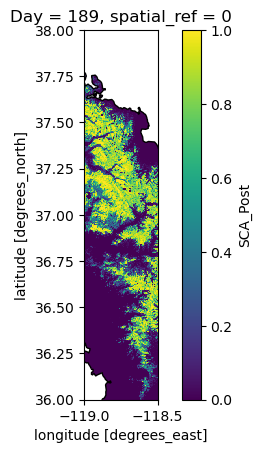

In [ ]:
fig, ax = plt.subplots()
reanalysis_2021.SCA_Post[atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==acq_dates[40])]['dowy'].unique()[0]].plot(ax=ax)
#atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==acq_dates[40]) & (atl06sr_gdf['reanalysis_fsca']>0.1)].plot(ax=ax, column='snow_depth', legend=True, vmin=-2, vmax=2, cmap='RdBu')
sierras.plot(ax=ax, facecolor='none', edgecolor='k')
plt.xlim(-119, -118.5)
plt.ylim(36,38)

<Axes: title={'center': 'Day = 189, spatial_ref = 0'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

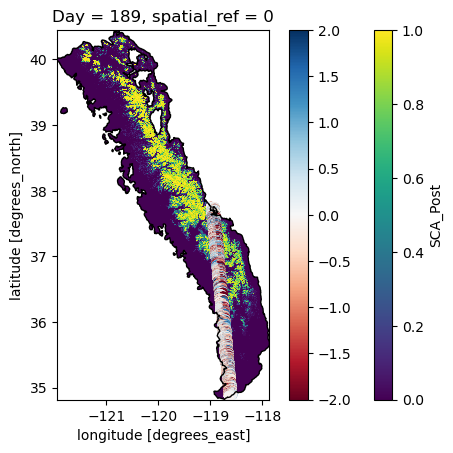

In [ ]:
fig, ax = plt.subplots()
reanalysis_2021.SCA_Post[atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==acq_dates[40])]['dowy'].unique()[0]].plot(ax=ax)
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==acq_dates[40])].plot(ax=ax, column='snow_depth', legend=True, vmin=-2, vmax=2, cmap='RdBu')
sierras.plot(ax=ax, facecolor='none', edgecolor='k')

<Axes: >

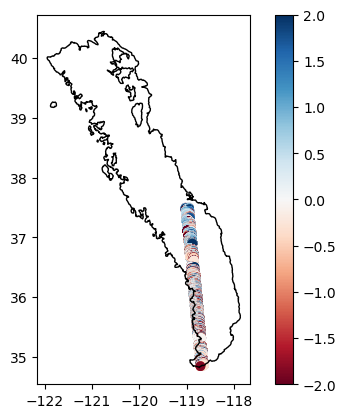

In [ ]:
fig, ax = plt.subplots()

atl06sr_gdf[atl06sr_gdf['acqdate']==acq_dates[46]].plot(ax=ax, column='snow_depth', legend=True, vmin=-2, vmax=2, cmap='RdBu')
sierras.plot(ax=ax, facecolor='none', edgecolor='k')

In [ ]:
acq_dates[40]

datetime.date(2021, 4, 7)

### Doesn't seem to be a snow signal. Compare to Tuolumne data from paper to check:

In [161]:
tuol = gpd.read_file('../data/misc/UpperTuolRiverBasinOutline.geojson')

<Axes: >

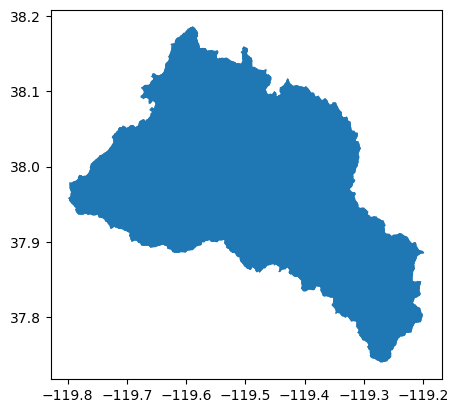

In [ ]:
tuol.plot()

In [ ]:
tuol_atl06sr = atl06sr_gdf.clip(tuol.to_crs(atl06sr_gdf.crs))

<Axes: >

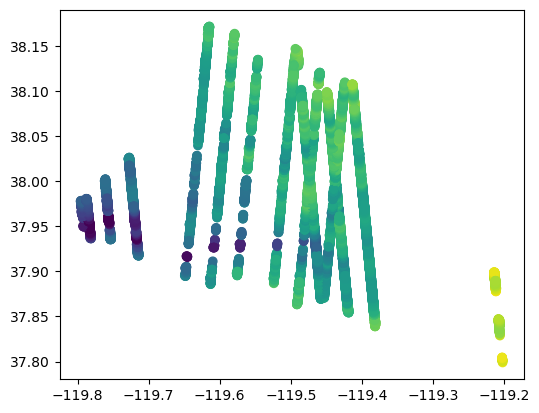

In [ ]:
tuol_atl06sr.plot(column='h_mean')

In [ ]:
atl06sr_orig = pickle.load(open('../data/icesat2/tuolumne_all_sr-atl06-09282022_processed_bicubic_snowonaso_shapely.pkl', 'rb'))

In [ ]:
atl06sr_orig.crs

<Projected CRS: EPSG:32611>
Name: WGS 84 / UTM zone 11N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 120°W and 114°W, northern hemisphere between equator and 84°N, onshore and offshore. Canada - Alberta; British Columbia (BC); Northwest Territories (NWT); Nunavut. Mexico. United States (USA).
- bounds: (-120.0, 0.0, -114.0, 84.0)
Coordinate Operation:
- name: UTM zone 11N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [ ]:
atl06sr_orig.columns

Index(['distance', 'h_sigma', 'rgt', 'delta_time', 'pflags', 'dh_fit_dy',
       'segment_id', 'w_surface_window_final', 'dh_fit_dx', 'h_mean', 'spot',
       'gt', 'cycle', 'rms_misfit', 'n_fit_photons', 'geometry', 'doy',
       'decyear', 'dowy', 'snow_presence', 'lidar_z', 'difference',
       'bicubic_lidar_z', 'sampling_dif', 'difference_bicubic', 'site',
       'acqdate', 'n', 'diff_plus', 'diff_plus_bicubic', 'zscore',
       'ASO_snowon', 'ASO_snowon_date', 'ASO_snowon_bic', 'median_slope20d'],
      dtype='object')

In [ ]:
atl06sr_orig_2021 = atl06sr_orig.loc['2020-10-01':'2021-09-30']

In [ ]:
atl06sr_orig_2021 = atl06sr_orig_2021.to_crs(tuol_atl06sr.crs)

<Axes: >

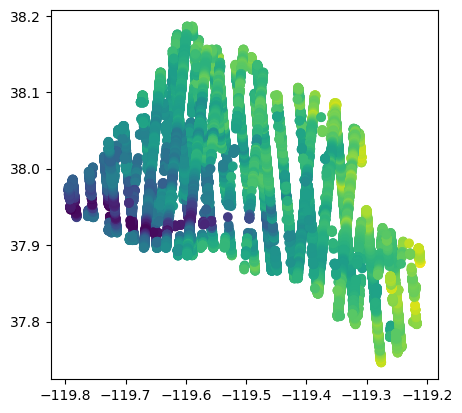

In [ ]:
atl06sr_orig_2021.plot(column='h_mean')

In [65]:
len(atl06sr_orig_2021['acqdate'].unique())

NameError: name 'atl06sr_orig_2021' is not defined

In [ ]:
tuol_atl06sr['acqdate'].unique()

array([datetime.date(2020, 12, 6), datetime.date(2021, 10, 4),
       datetime.date(2020, 12, 8), datetime.date(2020, 11, 9),
       datetime.date(2021, 4, 11), datetime.date(2021, 3, 13)],
      dtype=object)

<Axes: >

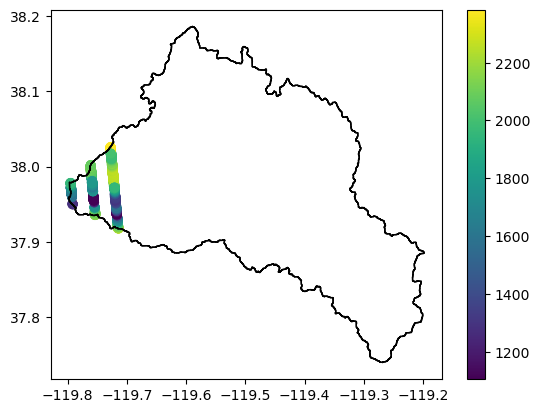

In [ ]:
fig, ax = plt.subplots()

tuol_atl06sr.loc['2021-04-11'].plot(ax=ax, column='h_mean', legend=True)
tuol.plot(ax=ax,facecolor='none')

In [ ]:
atl06sr_orig_2021.columns

Index(['distance', 'h_sigma', 'rgt', 'delta_time', 'pflags', 'dh_fit_dy',
       'segment_id', 'w_surface_window_final', 'dh_fit_dx', 'h_mean', 'spot',
       'gt', 'cycle', 'rms_misfit', 'n_fit_photons', 'geometry', 'doy',
       'decyear', 'dowy', 'snow_presence', 'lidar_z', 'difference',
       'bicubic_lidar_z', 'sampling_dif', 'difference_bicubic', 'site',
       'acqdate', 'n', 'diff_plus', 'diff_plus_bicubic', 'zscore',
       'ASO_snowon', 'ASO_snowon_date', 'ASO_snowon_bic', 'median_slope20d'],
      dtype='object')

<Axes: >

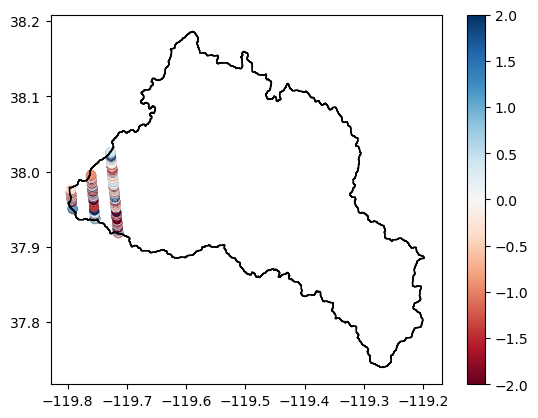

In [ ]:
fig, ax = plt.subplots()

atl06sr_orig_2021.loc['2021-04-11'].plot(ax=ax, column='difference', legend=True, vmin=-2, vmax=2, cmap='RdBu')
tuol.plot(ax=ax, facecolor='none')

<Axes: >

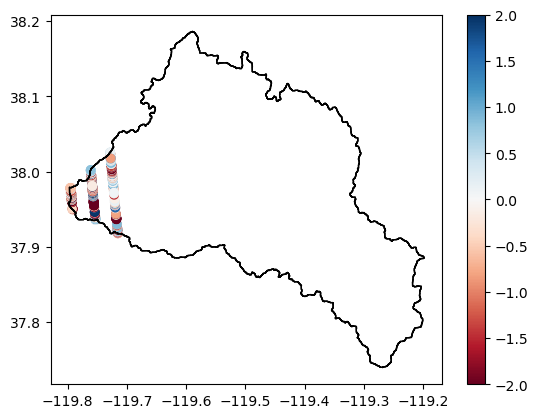

In [ ]:
fig, ax = plt.subplots()

tuol_atl06sr.loc['2021-04-11'].plot(ax=ax, column='snow_depth', legend=True, vmin=-2, vmax=2, cmap='RdBu')
tuol.plot(ax=ax, facecolor='none')

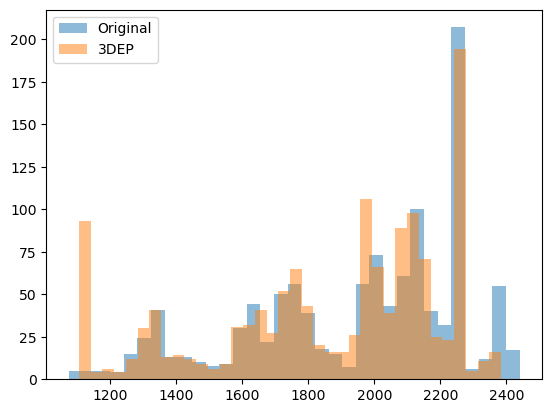

In [ ]:
fig, ax = plt.subplots()

ax.hist(atl06sr_orig_2021.loc['2021-04-11', 'h_mean'], bins=int(np.sqrt(len(atl06sr_orig_2021.loc['2021-04-11', 'difference']))), alpha=0.5, label='Original')
ax.hist(tuol_atl06sr.loc['2021-04-11', 'h_mean'], bins=int(np.sqrt(len(tuol_atl06sr.loc['2021-04-11', 'snow_depth']))), alpha=0.5, label='3DEP')
plt.legend()
#ax.set_xlim(-5, 5)

(-5.0, 5.0)

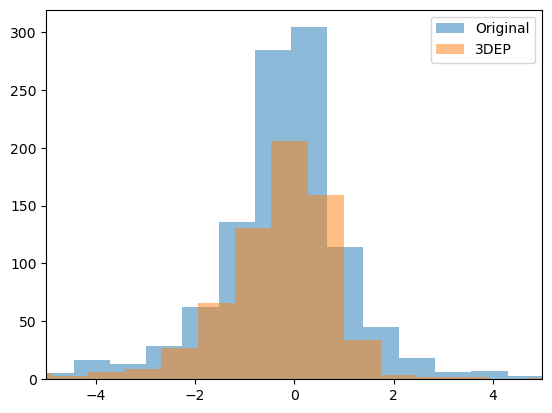

In [ ]:
fig, ax = plt.subplots()

ax.hist(atl06sr_orig_2021.loc['2021-04-11', 'difference'], bins=int(np.sqrt(len(atl06sr_orig_2021.loc['2021-04-11', 'difference']))), alpha=0.5, label='Original')
ax.hist(tuol_atl06sr.loc['2021-04-11', 'snow_depth'], bins=int(np.sqrt(len(tuol_atl06sr.loc['2021-04-11', 'snow_depth']))), alpha=0.5, label='3DEP')
plt.legend()
ax.set_xlim(-5, 5)


On the same date, the icesat-2 raw snow depth looks similar when accessed from SlideRule in different years, and using 3DEP 1m instead of ASO snow-off DEM for differencing. However, running SlideRule now for the entire Sierra in 2021 results in far fewer dates with data over Tuolumne. Whether sliderule isn't getting all dates, or it's getting all dates but patchy such that Tuolumne got missed on certain dates. 

### Remake the boxplot figures from the masters work:

In [11]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D
from astropy.time import Time
import datetime
#from rasterstats import zonal_stats
import pickle

In [13]:
import matplotlib.dates as mdates
import matplotlib.cbook as cbook

In [15]:
mpl_epoch = '1970-01-01'

In [17]:
from datetime import datetime

In [21]:
atl06sr_gdf['acqdate']

time
2021-10-12 07:30:24.762091008    2021-10-12
2021-10-12 07:30:24.759267328    2021-10-12
2021-10-12 07:30:24.753623040    2021-10-12
2021-10-12 07:30:24.750803456    2021-10-12
2021-10-12 07:30:24.747986176    2021-10-12
                                    ...    
2020-10-19 12:24:27.151114752    2020-10-19
2020-10-19 12:24:27.148294400    2020-10-19
2020-10-19 12:24:27.145472256    2020-10-19
2020-10-19 12:24:27.142647040    2020-10-19
2020-10-19 12:24:27.139817728    2020-10-19
Name: acqdate, Length: 859098, dtype: object

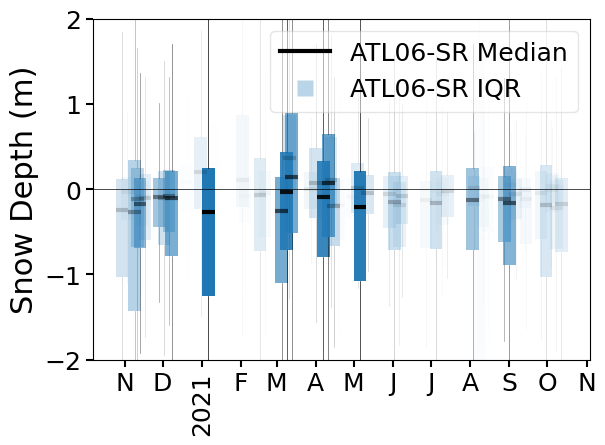

In [55]:
df=atl06sr_gdf
groupby_col='acqdate'
col='snow_depth'

bp_stats = df[[col, groupby_col]].dropna().groupby(groupby_col).apply(cbook.boxplot_stats)
bp_stats_list = [i[0] for i in bp_stats.values]
bp_alpha = df[[col, groupby_col]].dropna().groupby(groupby_col).count().values.ravel()
bp_alpha_boxes = bp_alpha/bp_alpha.max()
pos = (pd.to_datetime(bp_stats.index) - pd.to_datetime(mpl_epoch)).days.values

# dt_min_plot = '2020-10-01'
# dt_max_plot = '2021-09-30'
clim = (-2, 2)

fig, ax = plt.subplots()
bxp_f = ax.bxp(bp_stats_list, positions=pos, showfliers=False, showcaps=False, 
                   whiskerprops={'lw':0.5, 'alpha':0}, boxprops= {'lw':1, 'alpha':0.2},  
                   medianprops={'lw':3},widths=10, patch_artist=True)

for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    patch.set_edgecolor('None')
    patch.set_linewidth(0)

for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    patch.set_color('k')  # or deeppink 

 #set the ATL06SR alpha (transparency) for each box, whisker, and median according to the number of samples for that measurement
for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    patch.set_alpha(alpha)
    patch.set_edgecolor('None')
    patch.set_linewidth(0)
for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    patch.set_alpha(alpha)
    patch.set_color('k')  # or deeppink
#double the alpha list since there are 2 whiskers per box (https://datagy.io/python-combine-lists/)
for patch, alpha in zip(bxp_f['whiskers'], [item for sublist in zip(bp_alpha_boxes, bp_alpha_boxes) for item in sublist]):
    patch.set_alpha(alpha)

ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('Snow Depth (m)', fontsize=22)
ax.set_ylim(*clim)
# ax.set_xlim([dt_min_plot, dt_max_plot])

# X AXIS LABELS     
months = mdates.MonthLocator()
month_fmt = mdates.DateFormatter('%b')

def m_fmt(x, pos=None):
    return month_fmt(x)[0]

ax.xaxis.set_minor_locator(months) 
ax.xaxis.set_minor_formatter(FuncFormatter(m_fmt))

years = mdates.MonthLocator(bymonth=1)
ax.format_xdata = mdates.DateFormatter('%Y')
years_fmt = mdates.DateFormatter('%Y')
ax.xaxis.set_major_locator(years)
ax.xaxis.set_major_formatter(years_fmt)
ax.tick_params('both', length=5, width=1.5, which='major')
ax.tick_params('both', length=5, width=1.5, which='minor')
ax.legend(custom, custom_labels, loc='upper right', prop={'size':18}, fancybox=True, framealpha=0.5) #, fontsize=10

for label in ax.get_xticklabels(which='major'): #
    label.set(rotation=90, horizontalalignment='center')


plt.tight_layout()

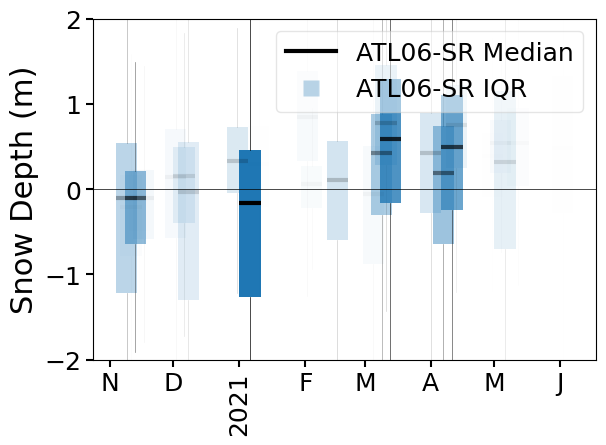

In [253]:
df=atl06sr_gdf[atl06sr_gdf['reanalysis_fsca']>0.5]
groupby_col='acqdate'
col='snow_depth_plus'

bp_stats = df[[col, groupby_col]].dropna().groupby(groupby_col).apply(cbook.boxplot_stats)
bp_stats_list = [i[0] for i in bp_stats.values]
bp_alpha = df[[col, groupby_col]].dropna().groupby(groupby_col).count().values.ravel()
bp_alpha_boxes = bp_alpha/bp_alpha.max()
pos = (pd.to_datetime(bp_stats.index) - pd.to_datetime(mpl_epoch)).days.values

# dt_min_plot = '2020-10-01'
# dt_max_plot = '2021-09-30'
clim = (-2, 2)

fig, ax = plt.subplots()
bxp_f = ax.bxp(bp_stats_list, positions=pos, showfliers=False, showcaps=False, 
                   whiskerprops={'lw':0.5, 'alpha':0}, boxprops= {'lw':1, 'alpha':0.2},  
                   medianprops={'lw':3},widths=10, patch_artist=True)

for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    patch.set_edgecolor('None')
    patch.set_linewidth(0)

for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    patch.set_color('k')  # or deeppink 

 #set the ATL06SR alpha (transparency) for each box, whisker, and median according to the number of samples for that measurement
for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    patch.set_alpha(alpha)
    patch.set_edgecolor('None')
    patch.set_linewidth(0)
for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    patch.set_alpha(alpha)
    patch.set_color('k')  # or deeppink
#double the alpha list since there are 2 whiskers per box (https://datagy.io/python-combine-lists/)
for patch, alpha in zip(bxp_f['whiskers'], [item for sublist in zip(bp_alpha_boxes, bp_alpha_boxes) for item in sublist]):
    patch.set_alpha(alpha)

ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('Snow Depth (m)', fontsize=22)
ax.set_ylim(*clim)
# ax.set_xlim([dt_min_plot, dt_max_plot])

# X AXIS LABELS     
months = mdates.MonthLocator()
month_fmt = mdates.DateFormatter('%b')

def m_fmt(x, pos=None):
    return month_fmt(x)[0]

ax.xaxis.set_minor_locator(months) 
ax.xaxis.set_minor_formatter(FuncFormatter(m_fmt))

years = mdates.MonthLocator(bymonth=1)
ax.format_xdata = mdates.DateFormatter('%Y')
years_fmt = mdates.DateFormatter('%Y')
ax.xaxis.set_major_locator(years)
ax.xaxis.set_major_formatter(years_fmt)
ax.tick_params('both', length=5, width=1.5, which='major')
ax.tick_params('both', length=5, width=1.5, which='minor')
ax.legend(custom, custom_labels, loc='upper right', prop={'size':18}, fancybox=True, framealpha=0.5) #, fontsize=10

for label in ax.get_xticklabels(which='major'): #
    label.set(rotation=90, horizontalalignment='center')


plt.tight_layout()

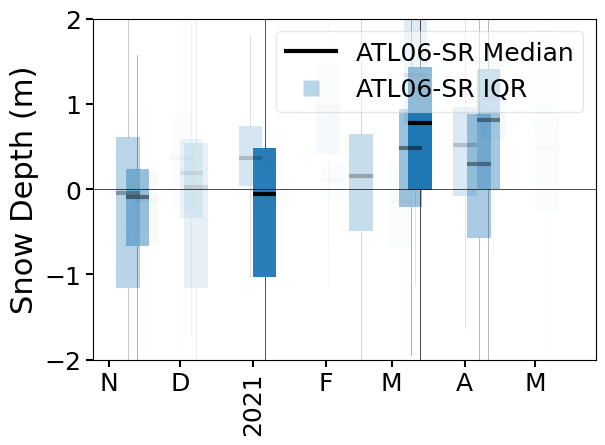

In [66]:
df=atl06sr_gdf[atl06sr_gdf['reanalysis_fsca']>0.9]
groupby_col='acqdate'
col='snow_depth_plus'

bp_stats = df[[col, groupby_col]].dropna().groupby(groupby_col).apply(cbook.boxplot_stats)
bp_stats_list = [i[0] for i in bp_stats.values]
bp_alpha = df[[col, groupby_col]].dropna().groupby(groupby_col).count().values.ravel()
bp_alpha_boxes = bp_alpha/bp_alpha.max()
pos = (pd.to_datetime(bp_stats.index) - pd.to_datetime(mpl_epoch)).days.values

# dt_min_plot = '2020-10-01'
# dt_max_plot = '2021-09-30'
clim = (-2, 2)

fig, ax = plt.subplots()
bxp_f = ax.bxp(bp_stats_list, positions=pos, showfliers=False, showcaps=False, 
                   whiskerprops={'lw':0.5, 'alpha':0}, boxprops= {'lw':1, 'alpha':0.2},  
                   medianprops={'lw':3},widths=10, patch_artist=True)

for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    patch.set_edgecolor('None')
    patch.set_linewidth(0)

for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    patch.set_color('k')  # or deeppink 

 #set the ATL06SR alpha (transparency) for each box, whisker, and median according to the number of samples for that measurement
for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    patch.set_alpha(alpha)
    patch.set_edgecolor('None')
    patch.set_linewidth(0)
for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    patch.set_alpha(alpha)
    patch.set_color('k')  # or deeppink
#double the alpha list since there are 2 whiskers per box (https://datagy.io/python-combine-lists/)
for patch, alpha in zip(bxp_f['whiskers'], [item for sublist in zip(bp_alpha_boxes, bp_alpha_boxes) for item in sublist]):
    patch.set_alpha(alpha)

ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('Snow Depth (m)', fontsize=22)
ax.set_ylim(*clim)
# ax.set_xlim([dt_min_plot, dt_max_plot])

# X AXIS LABELS     
months = mdates.MonthLocator()
month_fmt = mdates.DateFormatter('%b')

def m_fmt(x, pos=None):
    return month_fmt(x)[0]

ax.xaxis.set_minor_locator(months) 
ax.xaxis.set_minor_formatter(FuncFormatter(m_fmt))

years = mdates.MonthLocator(bymonth=1)
ax.format_xdata = mdates.DateFormatter('%Y')
years_fmt = mdates.DateFormatter('%Y')
ax.xaxis.set_major_locator(years)
ax.xaxis.set_major_formatter(years_fmt)
ax.tick_params('both', length=5, width=1.5, which='major')
ax.tick_params('both', length=5, width=1.5, which='minor')
ax.legend(custom, custom_labels, loc='upper right', prop={'size':18}, fancybox=True, framealpha=0.5) #, fontsize=10

for label in ax.get_xticklabels(which='major'): #
    label.set(rotation=90, horizontalalignment='center')


plt.tight_layout()

In [ ]:
# plot snotel plots throughout the sierra to compare
# find a place maybe in the north (more trees, less steep, denser snow, ros) or south (less trees, steeper, colder) that's smaller to look at. subset different basins to explore what's going on
# look at the american, feather, yuba?
# and redownload sliderule data to see if we're missing some points or dates
# see if i can use flagged snow cover and canopy cover in the icesat2 data - can i get this when downloading via sliderule?
# plot data with error bars from a one to one line by elevation, icesat2 versus reanalysis
# desiree used 10 degrees slope to subset

In [72]:
np.nanmin(atl06sr_gdf['h_mean'])

np.float64(1.102746284250586)

In [73]:
np.nanmax(atl06sr_gdf['h_mean'])

np.float64(4225.151067889545)

In [77]:
elev_min = np.arange(1000, 4400, 200)
elev_max = np.arange(1200, 4600, 200)
elev_max

array([1200, 1400, 1600, 1800, 2000, 2200, 2400, 2600, 2800, 3000, 3200,
       3400, 3600, 3800, 4000, 4200, 4400])

In [94]:
x_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    x_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_fsca']>0.9) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'snow_depth_plus'].values))

y_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    y_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_fsca']>0.9) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values))

x_std = []
for x_min, x_max in zip(elev_min, elev_max):
    x_std.append(np.nanstd(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_fsca']>0.9) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'snow_depth_plus'].values))

y_std = []
for x_min, x_max in zip(elev_min, elev_max):
    y_std.append(np.nanstd(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_fsca']>0.9) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values))


/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [95]:
x_std

[np.float64(1.218865929470245),
 np.float64(1.430562895361234),
 np.float64(1.1647472013985156),
 np.float64(0.893863463751636),
 np.float64(1.1084890213265195),
 np.float64(1.2251148917356116),
 np.float64(1.3102884873037897),
 np.float64(2.7906857466847548),
 np.float64(1.4116674436700742),
 np.float64(1.4703850549351005),
 np.float64(1.502162991383669),
 np.float64(1.5669668215151242),
 np.float64(1.3629268513504993),
 np.float64(1.7568276831025358),
 np.float64(2.802170601386212),
 np.float64(nan),
 np.float64(nan)]

Text(0, 0.5, 'Reanalysis Snow Depth (m)')

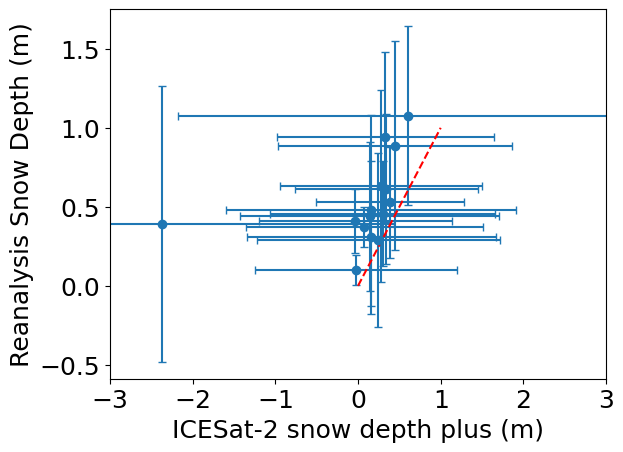

In [103]:
x = np.linspace(0, 1, 100) # Creates 100 points between x_min and x_max
y = x


fig, ax = plt.subplots()

plt.errorbar(x_medians, y_medians, xerr=x_std, yerr=y_std, fmt='o', capsize=3)
plt.plot(x, y, color='red', linestyle='--', label='1:1 Line')
plt.xlim(-3, 3)
#plt.ylim(-2,2)
plt.xlabel('ICESat-2 snow depth plus (m)')
plt.ylabel('Reanalysis Snow Depth (m)')

In [59]:
atl06sr_gdf['snow_depth_plus'] = atl06sr_gdf['snow_depth'] + abs(np.nanmedian(atl06sr_gdf.loc[atl06sr_gdf['reanalysis_fsca']==0, 'snow_depth']))

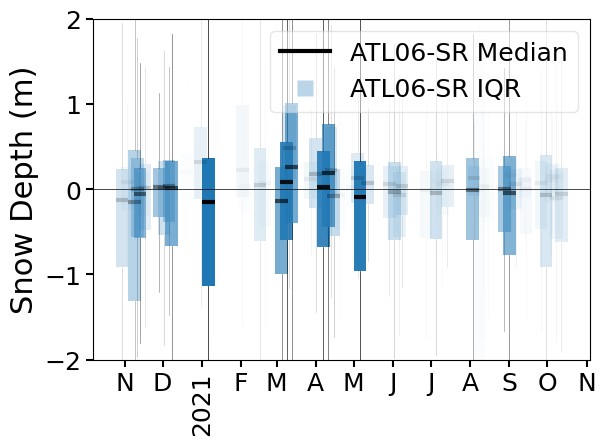

In [60]:
df=atl06sr_gdf
groupby_col='acqdate'
col='snow_depth_plus'

bp_stats = df[[col, groupby_col]].dropna().groupby(groupby_col).apply(cbook.boxplot_stats)
bp_stats_list = [i[0] for i in bp_stats.values]
bp_alpha = df[[col, groupby_col]].dropna().groupby(groupby_col).count().values.ravel()
bp_alpha_boxes = bp_alpha/bp_alpha.max()
pos = (pd.to_datetime(bp_stats.index) - pd.to_datetime(mpl_epoch)).days.values

# dt_min_plot = '2020-10-01'
# dt_max_plot = '2021-09-30'
clim = (-2, 2)

fig, ax = plt.subplots()
bxp_f = ax.bxp(bp_stats_list, positions=pos, showfliers=False, showcaps=False, 
                   whiskerprops={'lw':0.5, 'alpha':0}, boxprops= {'lw':1, 'alpha':0.2},  
                   medianprops={'lw':3},widths=10, patch_artist=True)

for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    patch.set_edgecolor('None')
    patch.set_linewidth(0)

for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    patch.set_color('k')  # or deeppink 

 #set the ATL06SR alpha (transparency) for each box, whisker, and median according to the number of samples for that measurement
for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    patch.set_alpha(alpha)
    patch.set_edgecolor('None')
    patch.set_linewidth(0)
for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    patch.set_alpha(alpha)
    patch.set_color('k')  # or deeppink
#double the alpha list since there are 2 whiskers per box (https://datagy.io/python-combine-lists/)
for patch, alpha in zip(bxp_f['whiskers'], [item for sublist in zip(bp_alpha_boxes, bp_alpha_boxes) for item in sublist]):
    patch.set_alpha(alpha)

ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('Snow Depth (m)', fontsize=22)
ax.set_ylim(*clim)
# ax.set_xlim([dt_min_plot, dt_max_plot])

# X AXIS LABELS     
months = mdates.MonthLocator()
month_fmt = mdates.DateFormatter('%b')

def m_fmt(x, pos=None):
    return month_fmt(x)[0]

ax.xaxis.set_minor_locator(months) 
ax.xaxis.set_minor_formatter(FuncFormatter(m_fmt))

years = mdates.MonthLocator(bymonth=1)
ax.format_xdata = mdates.DateFormatter('%Y')
years_fmt = mdates.DateFormatter('%Y')
ax.xaxis.set_major_locator(years)
ax.xaxis.set_major_formatter(years_fmt)
ax.tick_params('both', length=5, width=1.5, which='major')
ax.tick_params('both', length=5, width=1.5, which='minor')
ax.legend(custom, custom_labels, loc='upper right', prop={'size':18}, fancybox=True, framealpha=0.5) #, fontsize=10

for label in ax.get_xticklabels(which='major'): #
    label.set(rotation=90, horizontalalignment='center')


plt.tight_layout()

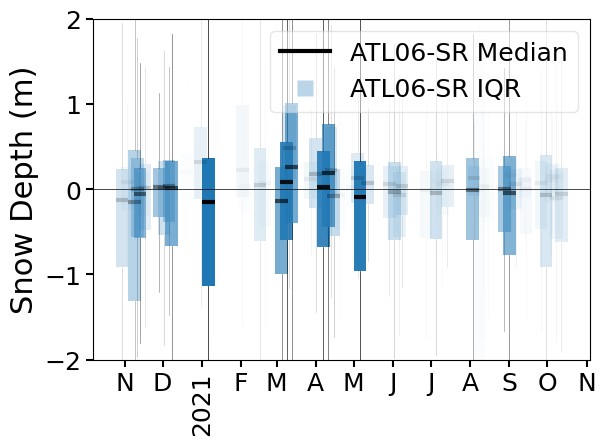

In [ ]:
df=atl06sr_gdf.loc[atl06sr_gdf['3dep']]
groupby_col='acqdate'
col='snow_depth_plus'

bp_stats = df[[col, groupby_col]].dropna().groupby(groupby_col).apply(cbook.boxplot_stats)
bp_stats_list = [i[0] for i in bp_stats.values]
bp_alpha = df[[col, groupby_col]].dropna().groupby(groupby_col).count().values.ravel()
bp_alpha_boxes = bp_alpha/bp_alpha.max()
pos = (pd.to_datetime(bp_stats.index) - pd.to_datetime(mpl_epoch)).days.values

# dt_min_plot = '2020-10-01'
# dt_max_plot = '2021-09-30'
clim = (-2, 2)

fig, ax = plt.subplots()
bxp_f = ax.bxp(bp_stats_list, positions=pos, showfliers=False, showcaps=False, 
                   whiskerprops={'lw':0.5, 'alpha':0}, boxprops= {'lw':1, 'alpha':0.2},  
                   medianprops={'lw':3},widths=10, patch_artist=True)

for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    patch.set_edgecolor('None')
    patch.set_linewidth(0)

for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    patch.set_color('k')  # or deeppink 

 #set the ATL06SR alpha (transparency) for each box, whisker, and median according to the number of samples for that measurement
for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    patch.set_alpha(alpha)
    patch.set_edgecolor('None')
    patch.set_linewidth(0)
for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    patch.set_alpha(alpha)
    patch.set_color('k')  # or deeppink
#double the alpha list since there are 2 whiskers per box (https://datagy.io/python-combine-lists/)
for patch, alpha in zip(bxp_f['whiskers'], [item for sublist in zip(bp_alpha_boxes, bp_alpha_boxes) for item in sublist]):
    patch.set_alpha(alpha)

ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('Snow Depth (m)', fontsize=22)
ax.set_ylim(*clim)
# ax.set_xlim([dt_min_plot, dt_max_plot])

# X AXIS LABELS     
months = mdates.MonthLocator()
month_fmt = mdates.DateFormatter('%b')

def m_fmt(x, pos=None):
    return month_fmt(x)[0]

ax.xaxis.set_minor_locator(months) 
ax.xaxis.set_minor_formatter(FuncFormatter(m_fmt))

years = mdates.MonthLocator(bymonth=1)
ax.format_xdata = mdates.DateFormatter('%Y')
years_fmt = mdates.DateFormatter('%Y')
ax.xaxis.set_major_locator(years)
ax.xaxis.set_major_formatter(years_fmt)
ax.tick_params('both', length=5, width=1.5, which='major')
ax.tick_params('both', length=5, width=1.5, which='minor')
ax.legend(custom, custom_labels, loc='upper right', prop={'size':18}, fancybox=True, framealpha=0.5) #, fontsize=10

for label in ax.get_xticklabels(which='major'): #
    label.set(rotation=90, horizontalalignment='center')


plt.tight_layout()

### Zoom in to smaller watersheds 

In [109]:

pwd

'/Users/hannah/Documents/Grad_Documents/Research/analog_snowmapping/notebooks'

In [121]:
huc10 = gpd.read_file('../data/misc/WBD_18_HU2_Shape/Shape/WBDHU10.shp')
huc10_2 = gpd.read_file('../data/misc/WBD_16_HU2_Shape2/Shape/WBDHU10.shp')

In [163]:
huc8 = gpd.read_file('../data/misc/WBD_18_HU2_Shape/Shape/WBDHU8.shp')
huc8_2 = gpd.read_file('../data/misc/WBD_16_HU2_Shape2/Shape/WBDHU8.shp')

In [164]:
huc8_clip = huc8.to_crs(sierras.crs).clip(sierras)
huc8_2_clip = huc8_2.to_crs(sierras.crs).clip(sierras)
huc8_sierra = pd.concat([huc8_clip, huc8_2_clip], ignore_index=True)

<Axes: >

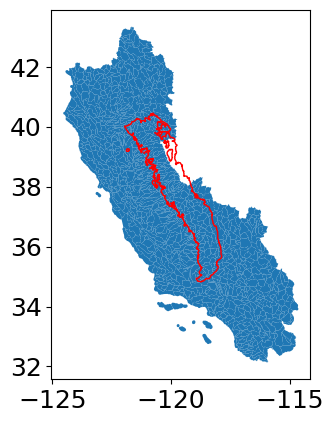

In [118]:
fig, ax = plt.subplots()
huc10.plot(ax=ax)
sierras.plot(ax=ax, facecolor='none', edgecolor='r')

In [115]:
huc10.crs

<Geographic 2D CRS: EPSG:4269>
Name: NAD83
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: North America - onshore and offshore: Canada - Alberta; British Columbia; Manitoba; New Brunswick; Newfoundland and Labrador; Northwest Territories; Nova Scotia; Nunavut; Ontario; Prince Edward Island; Quebec; Saskatchewan; Yukon. Puerto Rico. United States (USA) - Alabama; Alaska; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Hawaii; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; Missouri; Montana; Nebraska; Nevada; New Hampshire; New Jersey; New Mexico; New York; North Carolina; North Dakota; Ohio; Oklahoma; Oregon; Pennsylvania; Rhode Island; South Carolina; South Dakota; Tennessee; Texas; Utah; Vermont; Virginia; Washington; West Virginia; Wisconsin; Wyoming. US Virgin Islands. British Virgin Islands

<Axes: >

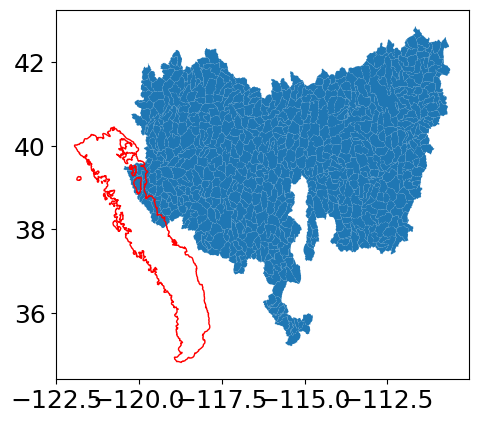

In [122]:
fig, ax = plt.subplots()
huc10_2.plot(ax=ax)
sierras.plot(ax=ax, facecolor='none', edgecolor='r')

In [124]:
huc10_clip = huc10.to_crs(sierras.crs).clip(sierras)
huc10_2_clip = huc10_2.to_crs(sierras.crs).clip(sierras)
huc10_sierra = pd.concat([huc10_clip, huc10_2_clip], ignore_index=True)

<Axes: >

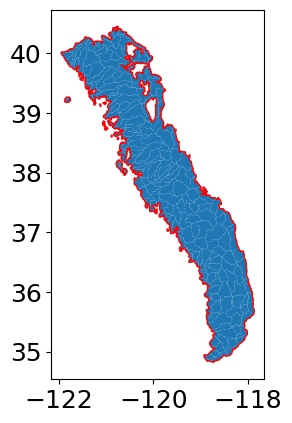

In [133]:
fig, ax = plt.subplots()
huc10_sierra.plot(ax=ax)
sierras.plot(ax=ax, facecolor='none', edgecolor='r')

<Axes: >

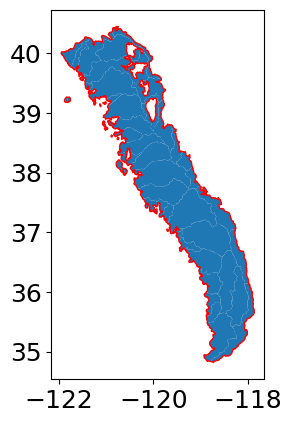

In [165]:
fig, ax = plt.subplots()
huc8_sierra.plot(ax=ax)
sierras.plot(ax=ax, facecolor='none', edgecolor='r')

In [223]:
huc8_sierra.loc[(huc8_sierra['name'].str.contains('American')), 'name']

21    South Fork American
22    North Fork American
Name: name, dtype: object

<Axes: >

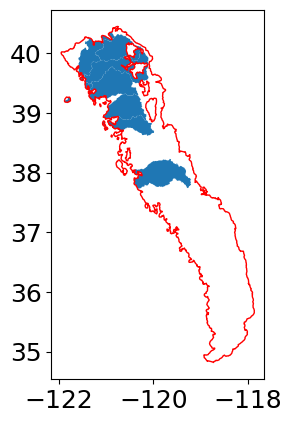

In [227]:
fig, ax = plt.subplots()
huc8_sierra[(huc8_sierra['name'].str.contains('American|Feather|Tuolumne|Yuba'))].plot(ax=ax)
sierras.plot(ax=ax, facecolor='none', edgecolor='r')

#huc10_sierra[huc10_sierra['name']=='Upper North Fork American River'].plot()

In [ ]:
# build in a filter to see how different the weak and strong beams are, and filter out the weak beam if needed.
# need to figure out if the large negaive values are due to canopy or slope or elevation
# within each huc8 watershed, also look at the snow-off data and see if there's a consistent offset in the snow-off values 

In [169]:
atl06sr_american = atl06sr_gdf.clip(huc8_sierra[huc8_sierra['name'].str.contains('American')].geometry.to_crs(atl06sr_gdf.crs))

<Axes: >

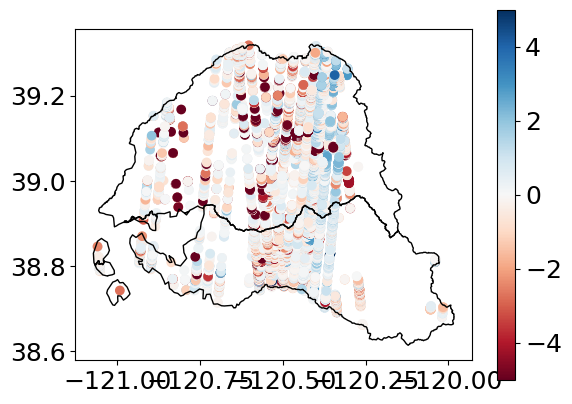

In [170]:
fig, ax = plt.subplots()

atl06sr_american.plot(column='snow_depth_plus', ax=ax, legend=True, vmin=-5, vmax=5, cmap='RdBu')
huc8_sierra[huc8_sierra['name'].str.contains('American')].plot(ax=ax, facecolor='none', edgecolor='k')


In [184]:
def plot_reanalysis_dif(df, snow_column, poly):
    acq_dates = list(df[snow_column].unique())
    for date_index in acq_dates:
        # plot a histogram of the snow-on reanalysis and IS2 data, and display the median values for the basin in the legend title:

        atl06_subset = df.loc[(df['acqdate']==date_index) & (df['reanalysis_fsca']>0.9)][snow_column]
        reanalysis_subset = df.loc[(df['acqdate']==date_index) & (df['reanalysis_fsca']>0.9)]['reanalysis_sd']

        if int(np.sqrt(len(atl06_subset))) > 10:
            fig1, ax = plt.subplots()
            ax.hist(atl06_subset, bins=int(np.sqrt(len(atl06_subset))), \
                            alpha=0.7, label='ATL06-SR')
            ax.hist(reanalysis_subset, bins=int(np.sqrt(len(reanalysis_subset))), \
                            alpha=0.7, label='Reanalysis')
            ax.axvline(x = np.nanmedian(atl06_subset), linewidth=2, color='blue')
            ax.axvline(x = np.nanmedian(reanalysis_subset), linewidth=2, color='red')
            plt.xlim(-5, 5)
            plt.title(f'{acq_dates[date_index]}')
            plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06_subset):.2f}, reanalysis median: {np.nanmedian(reanalysis_subset):.2f}')

            
            # Plot the reanaysis snow depth where fsca > 0.1, and icesat2 data where fsca > 0.1:

            fig2, ax = plt.subplots()
            #reanalysis_subset.plot(ax=ax, vmax=2)
            poly.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
            df.loc[(df['acqdate']==date_index) & (df['reanalysis_fsca']>0.9)].to_crs('epsg:4326').plot(column=snow_column,ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
            plt.title(f'{date_index}')
            return fig1, fig2
        else: continue


## North Sierra:  

### American River:

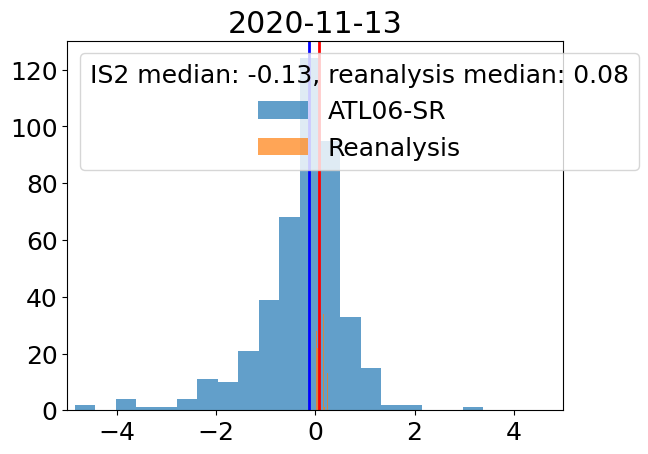

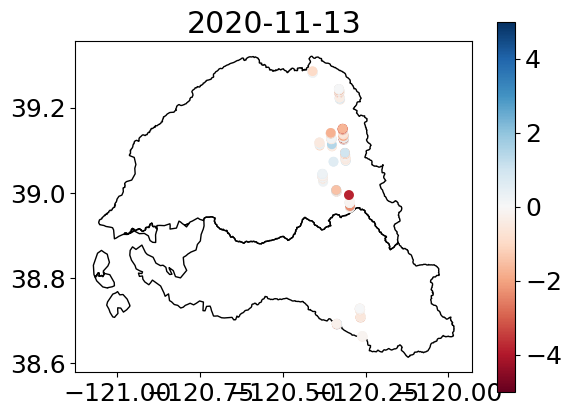

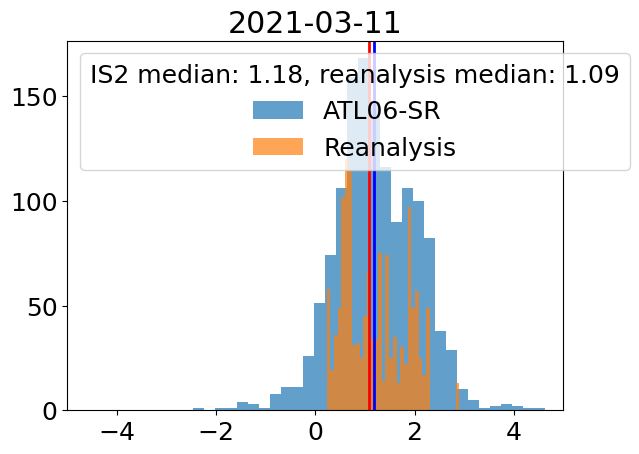

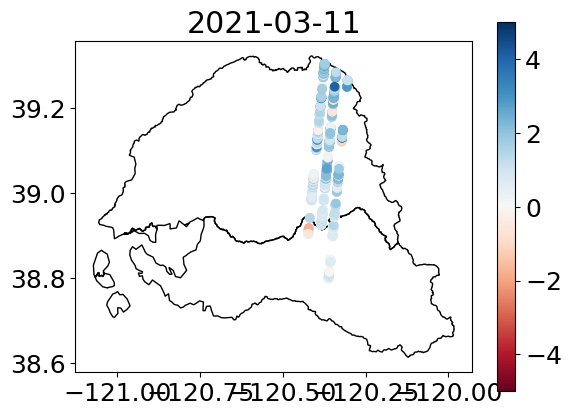

In [248]:
df = atl06sr_american
snow_column='snow_depth_plus'
acq_dates = list(df['acqdate'].unique())
poly = huc8_sierra[huc8_sierra['name'].str.contains('American')]

for date_index in acq_dates:
    # plot a histogram of the snow-on reanalysis and IS2 data, and display the median values for the basin in the legend title:

    atl06_subset = df.loc[(df['acqdate']==date_index) & (df['reanalysis_fsca']>0.9)][snow_column]
    reanalysis_subset = df.loc[(df['acqdate']==date_index) & (df['reanalysis_fsca']>0.9)]['reanalysis_sd']

    if int(np.sqrt(len(atl06_subset))) > 10:
        fig, ax = plt.subplots()
        ax.hist(atl06_subset, bins=int(np.sqrt(len(atl06_subset))), \
                        alpha=0.7, label='ATL06-SR')
        ax.hist(reanalysis_subset, bins=int(np.sqrt(len(reanalysis_subset))), \
                        alpha=0.7, label='Reanalysis')
        ax.axvline(x = np.nanmedian(atl06_subset), linewidth=2, color='blue')
        ax.axvline(x = np.nanmedian(reanalysis_subset), linewidth=2, color='red')
        plt.xlim(-5, 5)
        plt.title(f'{date_index}')
        plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06_subset):.2f}, reanalysis median: {np.nanmedian(reanalysis_subset):.2f}')

        
        # Plot the reanaysis snow depth where fsca > 0.1, and icesat2 data where fsca > 0.1:

        fig, ax = plt.subplots()
        #reanalysis_subset.plot(ax=ax, vmax=2)
        poly.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
        df.loc[(df['acqdate']==date_index) & (df['reanalysis_fsca']>0.9)].to_crs('epsg:4326').plot(column=snow_column,ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
        plt.title(f'{date_index}')
        
    else: continue

### Tuolumne Basin:

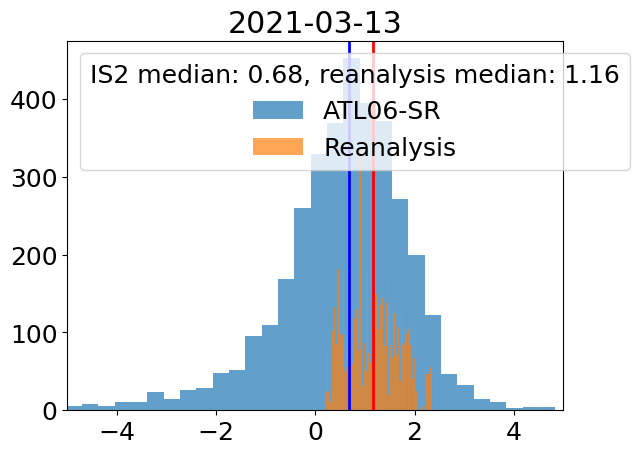

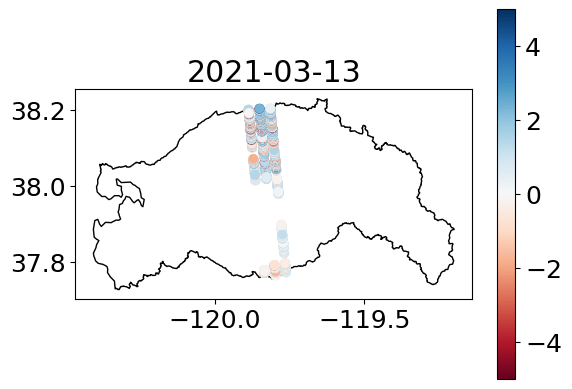

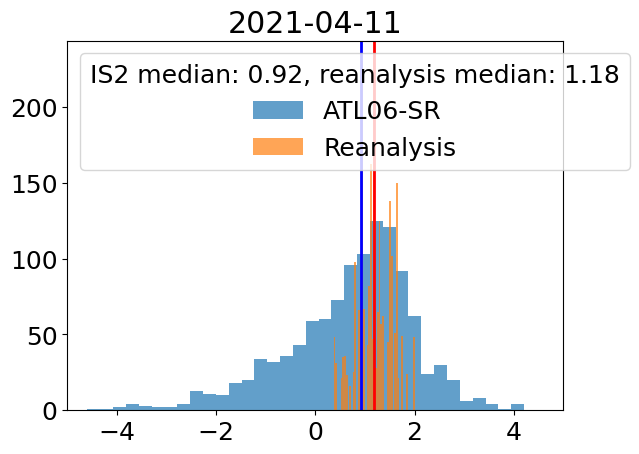

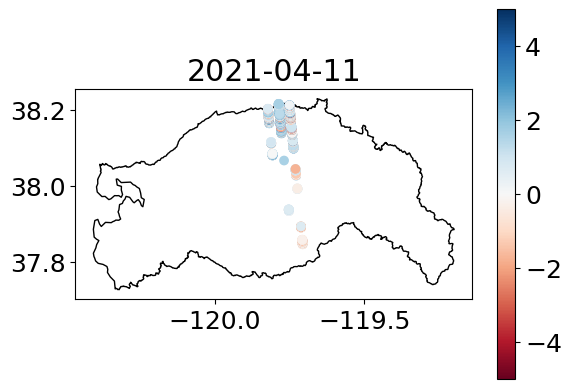

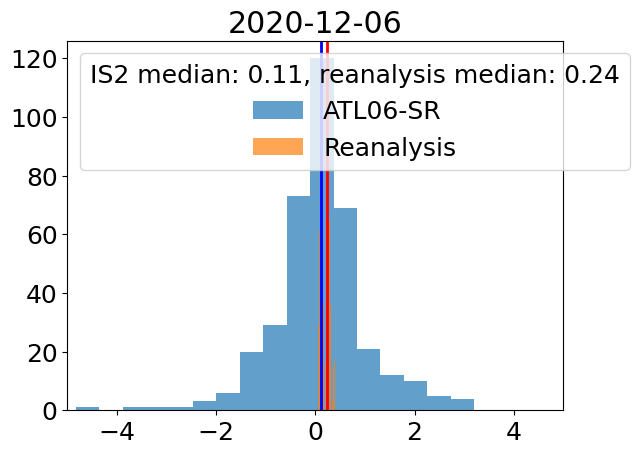

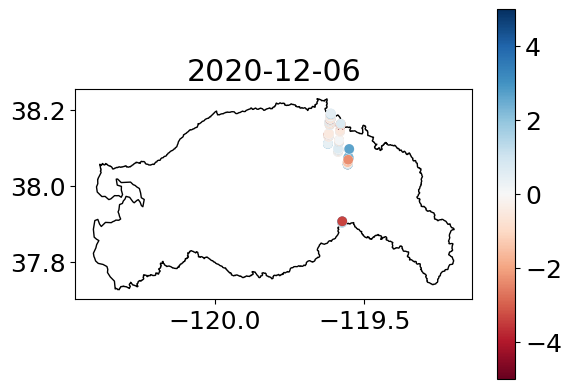

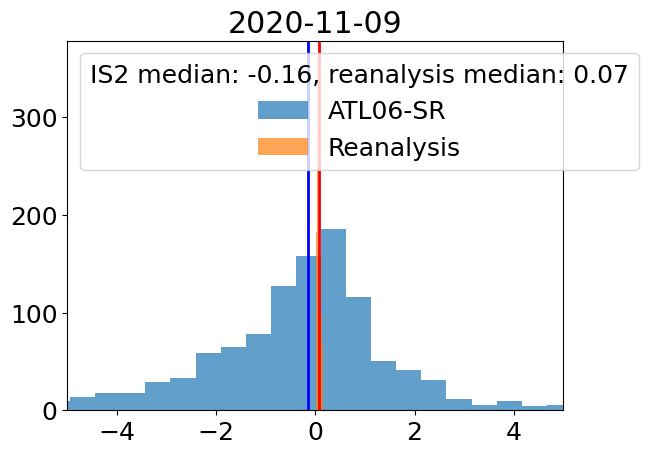

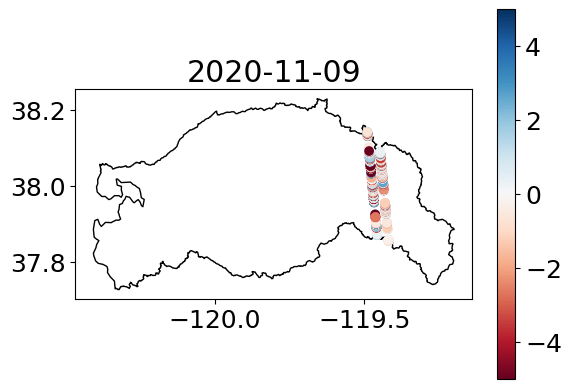

In [247]:
df = atl06sr_gdf.clip(huc8_sierra[huc8_sierra['name'].str.contains('Tuolumne')].geometry.to_crs(atl06sr_gdf.crs))
snow_column='snow_depth_plus'
acq_dates = list(df['acqdate'].unique())
poly = huc8_sierra[huc8_sierra['name'].str.contains('Tuolumne')]

for date_index in acq_dates:
    # plot a histogram of the snow-on reanalysis and IS2 data, and display the median values for the basin in the legend title:

    atl06_subset = df.loc[(df['acqdate']==date_index) & (df['reanalysis_fsca']>0.9)][snow_column]
    reanalysis_subset = df.loc[(df['acqdate']==date_index) & (df['reanalysis_fsca']>0.9)]['reanalysis_sd']

    if int(np.sqrt(len(atl06_subset))) > 10:
        fig, ax = plt.subplots()
        ax.hist(atl06_subset, bins=int(np.sqrt(len(atl06_subset))), \
                        alpha=0.7, label='ATL06-SR')
        ax.hist(reanalysis_subset, bins=int(np.sqrt(len(reanalysis_subset))), \
                        alpha=0.7, label='Reanalysis')
        ax.axvline(x = np.nanmedian(atl06_subset), linewidth=2, color='blue')
        ax.axvline(x = np.nanmedian(reanalysis_subset), linewidth=2, color='red')
        plt.xlim(-5, 5)
        plt.title(f'{date_index}')
        plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06_subset):.2f}, reanalysis median: {np.nanmedian(reanalysis_subset):.2f}')

        
        # Plot the reanaysis snow depth where fsca > 0.1, and icesat2 data where fsca > 0.1:

        fig, ax = plt.subplots()
        #reanalysis_subset.plot(ax=ax, vmax=2)
        poly.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
        df.loc[(df['acqdate']==date_index) & (df['reanalysis_fsca']>0.9)].to_crs('epsg:4326').plot(column=snow_column,ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
        plt.title(f'{date_index}')
        
    else: continue

<Axes: >

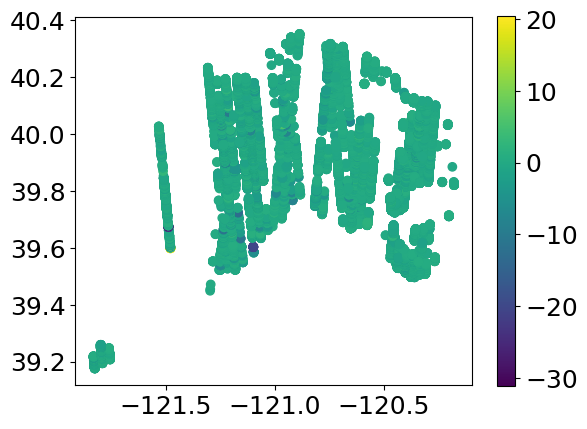

In [205]:
df.plot(column=snow_column, legend=True)

### Feather Basin:

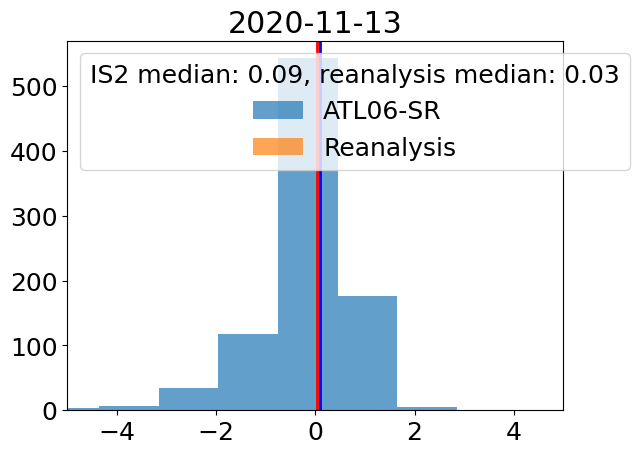

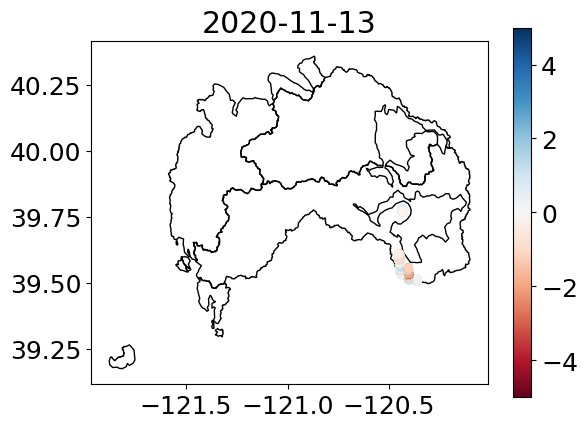

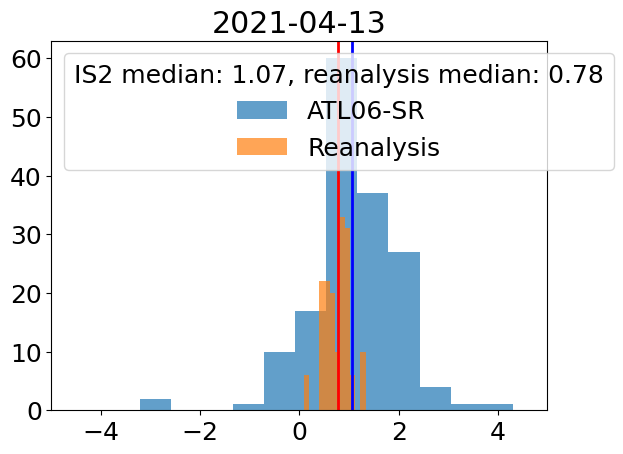

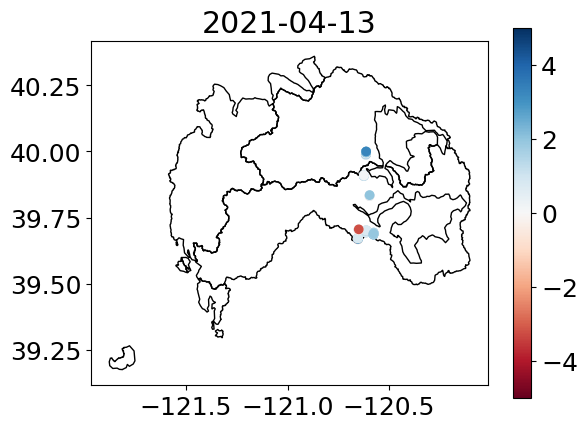

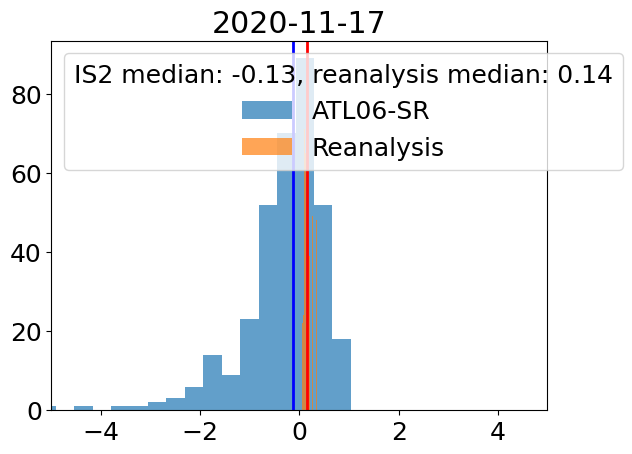

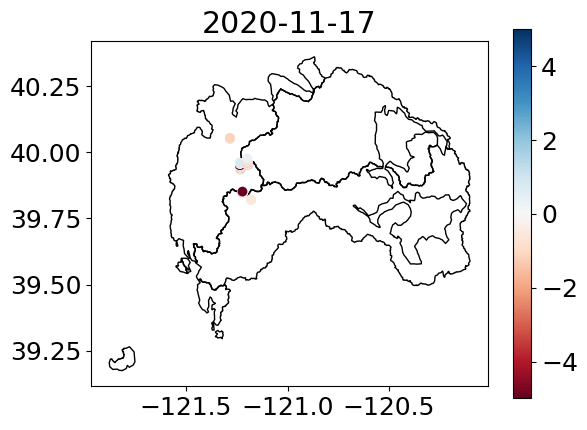

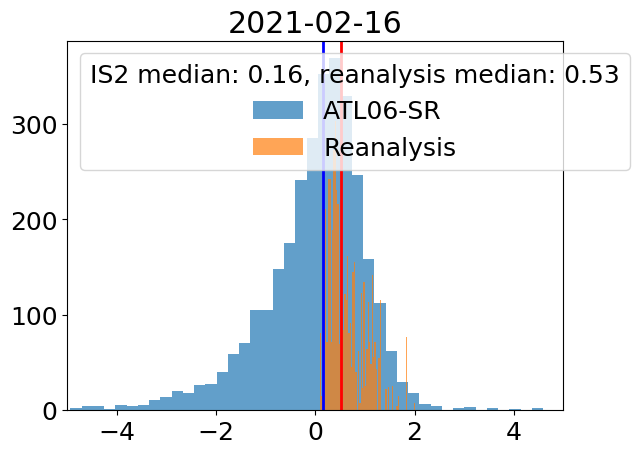

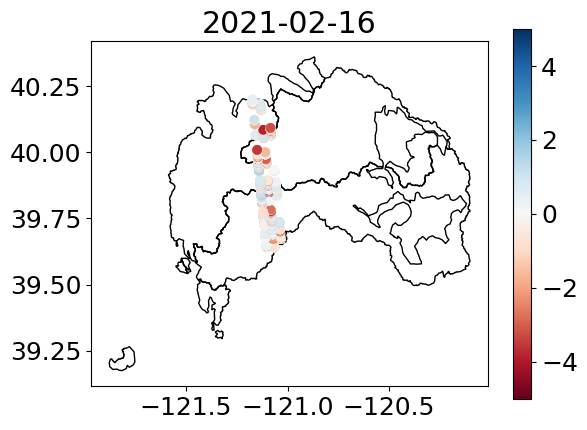

In [246]:
df = atl06sr_gdf.clip(huc8_sierra[huc8_sierra['name'].str.contains('Feather')].geometry.to_crs(atl06sr_gdf.crs))
snow_column='snow_depth_plus'
acq_dates = list(df['acqdate'].unique())
poly = huc8_sierra[huc8_sierra['name'].str.contains('Feather')]

for date_index in acq_dates:
    # plot a histogram of the snow-on reanalysis and IS2 data, and display the median values for the basin in the legend title:

    atl06_subset = df.loc[(df['acqdate']==date_index) & (df['reanalysis_fsca']>0.9)][snow_column]
    reanalysis_subset = df.loc[(df['acqdate']==date_index) & (df['reanalysis_fsca']>0.9)]['reanalysis_sd']

    len_atl06_subset = len(atl06_subset[~np.isnan(atl06_subset)])

    if int(np.sqrt(len_atl06_subset)) > 7:
        fig, ax = plt.subplots()
        ax.hist(atl06_subset, bins=int(np.sqrt(len_atl06_subset)), \
                        alpha=0.7, label='ATL06-SR')
        ax.hist(reanalysis_subset, bins=int(np.sqrt(len(reanalysis_subset[~np.isnan(reanalysis_subset)]))), \
                        alpha=0.7, label='Reanalysis')
        ax.axvline(x = np.nanmedian(atl06_subset), linewidth=2, color='blue')
        ax.axvline(x = np.nanmedian(reanalysis_subset), linewidth=2, color='red')
        plt.xlim(-5, 5)
        plt.title(f'{date_index}')
        plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06_subset):.2f}, reanalysis median: {np.nanmedian(reanalysis_subset):.2f}')

        
        # Plot the reanaysis snow depth where fsca > 0.1, and icesat2 data where fsca > 0.1:

        fig, ax = plt.subplots()
        #reanalysis_subset.plot(ax=ax, vmax=2)
        poly.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
        df.loc[(df['acqdate']==date_index) & (df['reanalysis_fsca']>0.9)].to_crs('epsg:4326').plot(column=snow_column,ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
        plt.title(f'{date_index}')
        
    else: continue

### Yuba River:

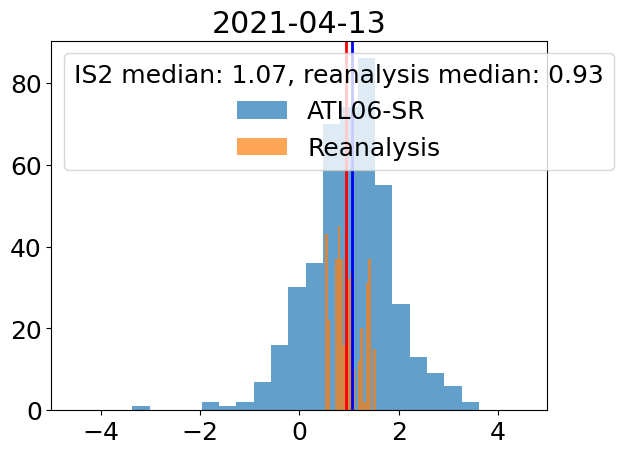

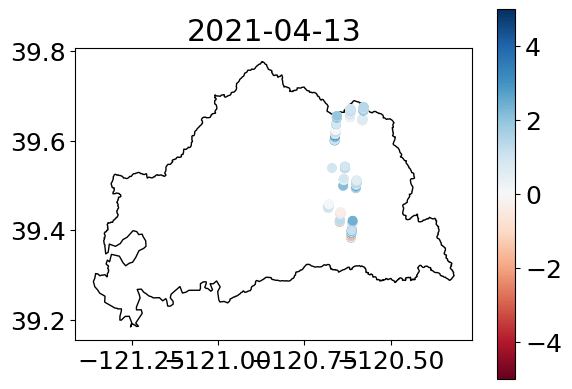

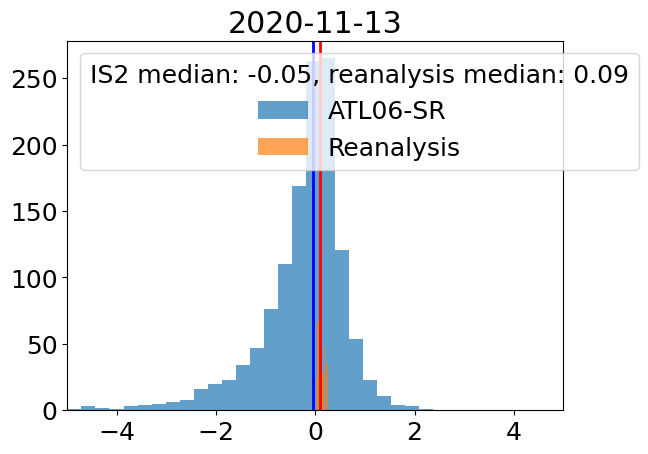

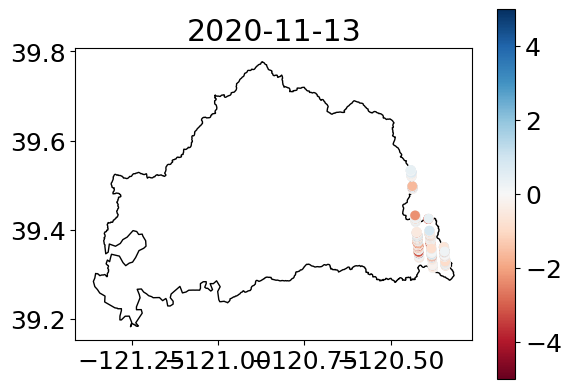

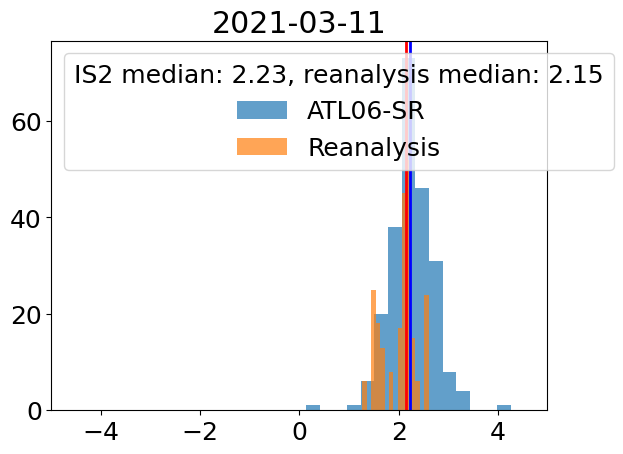

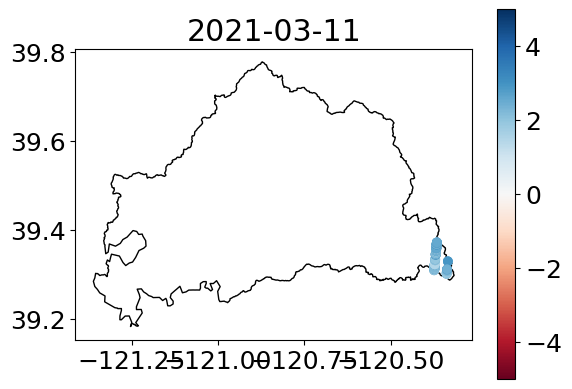

In [245]:
df = atl06sr_gdf.clip(huc8_sierra[huc8_sierra['name'].str.contains('Yuba')].geometry.to_crs(atl06sr_gdf.crs))
snow_column='snow_depth_plus'
acq_dates = list(df['acqdate'].unique())
poly = huc8_sierra[huc8_sierra['name'].str.contains('Yuba')]

for date_index in acq_dates:
    # plot a histogram of the snow-on reanalysis and IS2 data, and display the median values for the basin in the legend title:

    atl06_subset = df.loc[(df['acqdate']==date_index) & (df['reanalysis_fsca']>0.9)][snow_column]
    reanalysis_subset = df.loc[(df['acqdate']==date_index) & (df['reanalysis_fsca']>0.9)]['reanalysis_sd']

    len_atl06_subset = len(atl06_subset[~np.isnan(atl06_subset)])

    if int(np.sqrt(len_atl06_subset)) > 10:
        fig, ax = plt.subplots()
        ax.hist(atl06_subset, bins=int(np.sqrt(len_atl06_subset)), \
                        alpha=0.7, label='ATL06-SR')
        ax.hist(reanalysis_subset, bins=int(np.sqrt(len(reanalysis_subset[~np.isnan(reanalysis_subset)]))), \
                        alpha=0.7, label='Reanalysis')
        ax.axvline(x = np.nanmedian(atl06_subset), linewidth=2, color='blue')
        ax.axvline(x = np.nanmedian(reanalysis_subset), linewidth=2, color='red')
        plt.xlim(-5, 5)
        plt.title(f'{date_index}')
        plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06_subset):.2f}, reanalysis median: {np.nanmedian(reanalysis_subset):.2f}')

        
        # Plot the reanaysis snow depth where fsca > 0.1, and icesat2 data where fsca > 0.1:

        fig, ax = plt.subplots()
        #reanalysis_subset.plot(ax=ax, vmax=2)
        poly.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
        df.loc[(df['acqdate']==date_index) & (df['reanalysis_fsca']>0.9)].to_crs('epsg:4326').plot(column=snow_column,ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
        plt.title(f'{date_index}')
        
    else: continue

For some dates and watersheds, this seems feasible. For others, it doesn't. Waiting on the slope calculations hoping that slope plays a role in determining where we can use IS2. Otherwise, waiting on SR to stabilize the amount of data that gets downloaded over large areas, at which point I'll rerun the download with the additional attributes from the original products to include canopy cover, azimuth angle, landcover type, snowcover, etc. 

## South Sierra:  |

<Axes: >

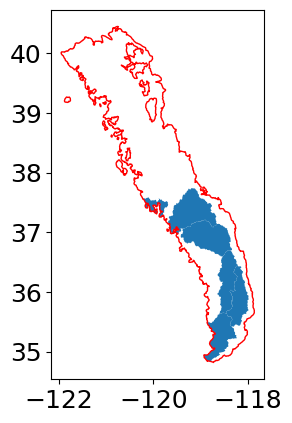

In [ ]:
fig, ax = plt.subplots()
huc8_sierra[(huc8_sierra['name'].str.contains('Kern|San Joaquin|King'))].plot(ax=ax)
sierras.plot(ax=ax, facecolor='none', edgecolor='r')

### Kern River:

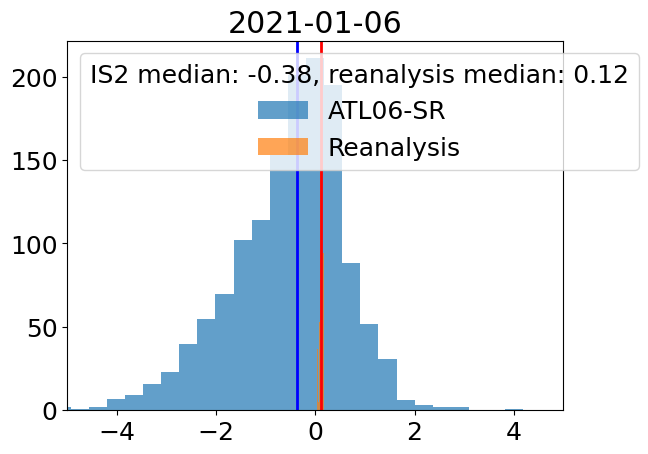

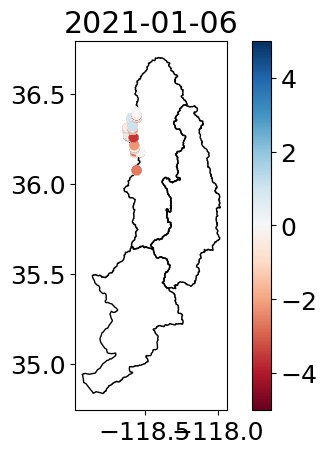

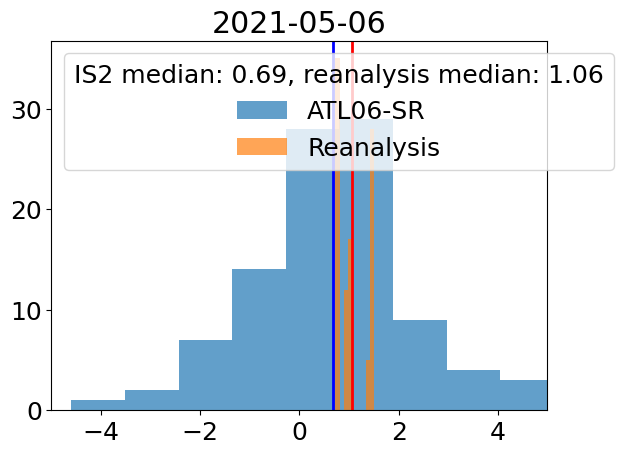

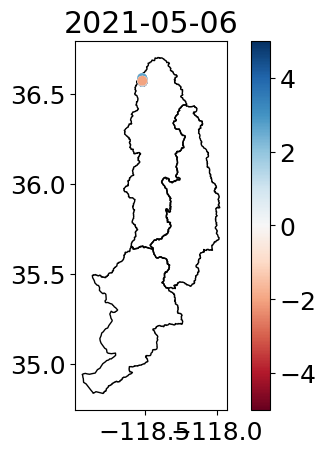

In [244]:
df = atl06sr_gdf.clip(huc8_sierra[huc8_sierra['name'].str.contains('Kern')].geometry.to_crs(atl06sr_gdf.crs))
snow_column='snow_depth_plus'
acq_dates = list(df['acqdate'].unique())
poly = huc8_sierra[huc8_sierra['name'].str.contains('Kern')]

for date_index in acq_dates:
    # plot a histogram of the snow-on reanalysis and IS2 data, and display the median values for the basin in the legend title:

    atl06_subset = df.loc[(df['acqdate']==date_index) & (df['reanalysis_fsca']>0.9)][snow_column]
    reanalysis_subset = df.loc[(df['acqdate']==date_index) & (df['reanalysis_fsca']>0.9)]['reanalysis_sd']

    len_atl06_subset = len(atl06_subset[~np.isnan(atl06_subset)])

    if int(np.sqrt(len_atl06_subset)) > 7:
        fig, ax = plt.subplots()
        ax.hist(atl06_subset, bins=int(np.sqrt(len_atl06_subset)), \
                        alpha=0.7, label='ATL06-SR')
        ax.hist(reanalysis_subset, bins=int(np.sqrt(len(reanalysis_subset[~np.isnan(reanalysis_subset)]))), \
                        alpha=0.7, label='Reanalysis')
        ax.axvline(x = np.nanmedian(atl06_subset), linewidth=2, color='blue')
        ax.axvline(x = np.nanmedian(reanalysis_subset), linewidth=2, color='red')
        plt.xlim(-5, 5)
        plt.title(f'{date_index}')
        plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06_subset):.2f}, reanalysis median: {np.nanmedian(reanalysis_subset):.2f}')

        
        # Plot the reanaysis snow depth where fsca > 0.1, and icesat2 data where fsca > 0.1:

        fig, ax = plt.subplots()
        #reanalysis_subset.plot(ax=ax, vmax=2)
        poly.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
        df.loc[(df['acqdate']==date_index) & (df['reanalysis_fsca']>0.9)].to_crs('epsg:4326').plot(column=snow_column,ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
        plt.title(f'{date_index}')
        
    else: continue

### King River:

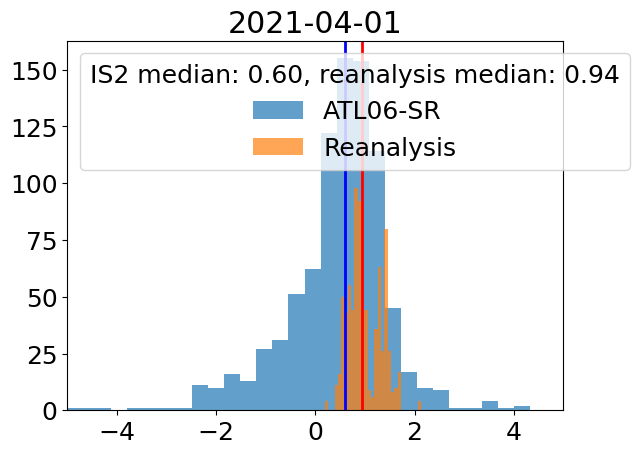

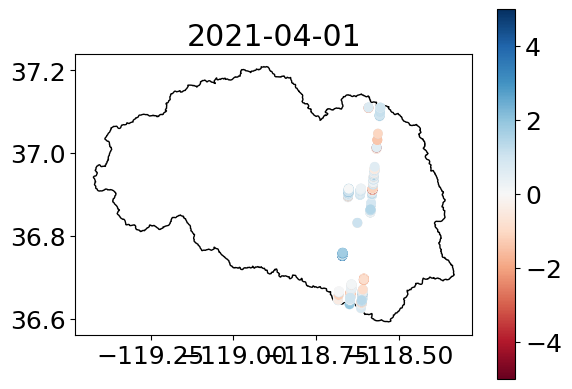

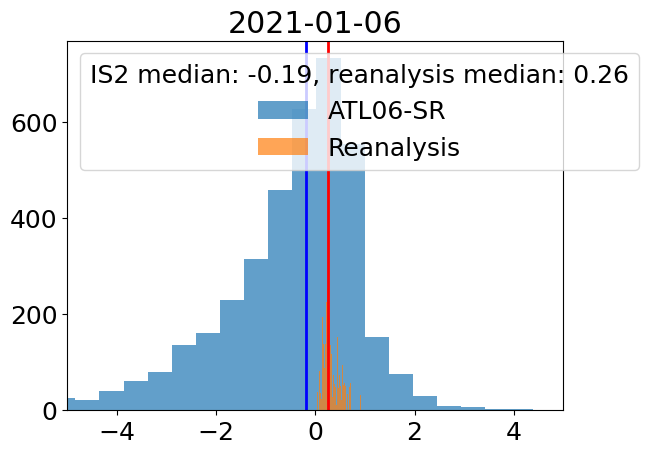

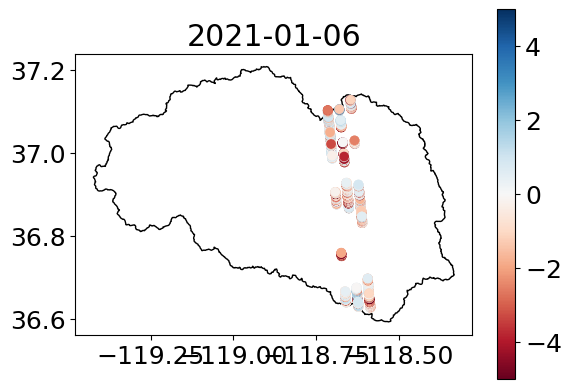

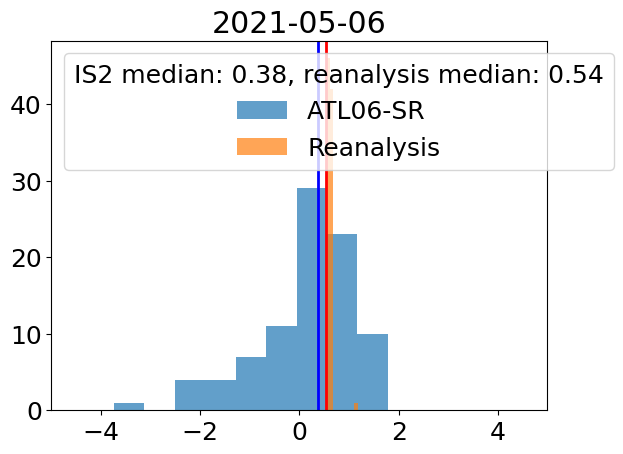

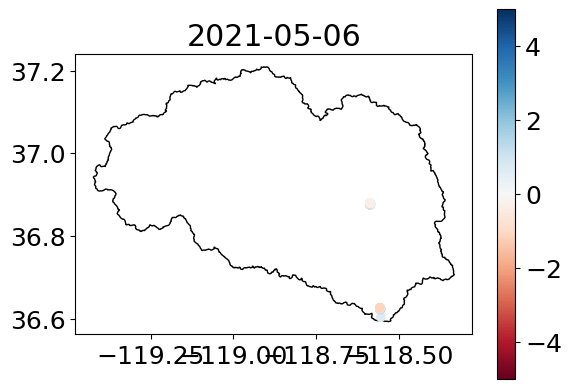

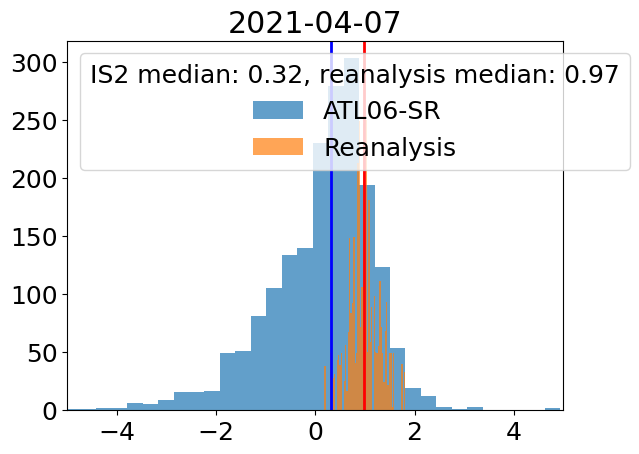

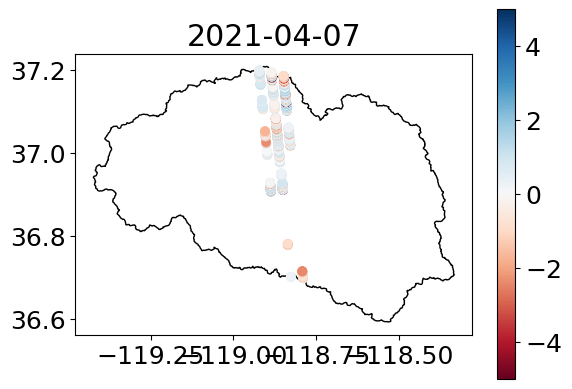

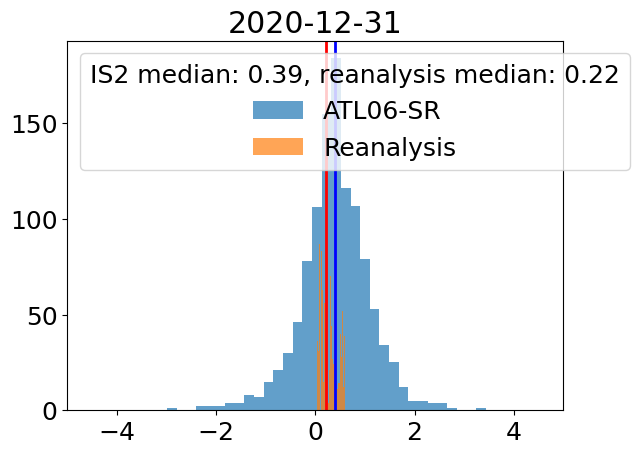

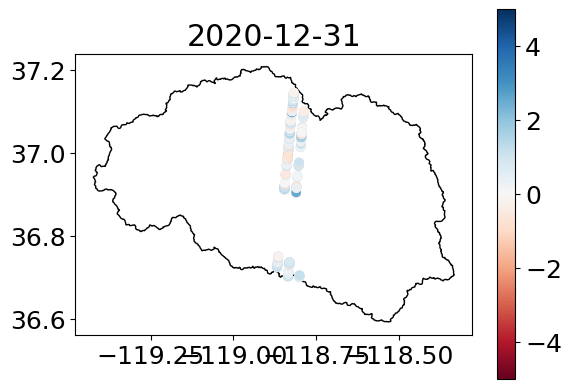

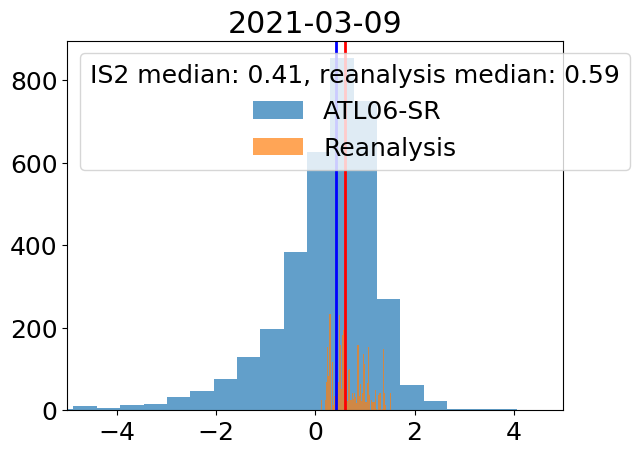

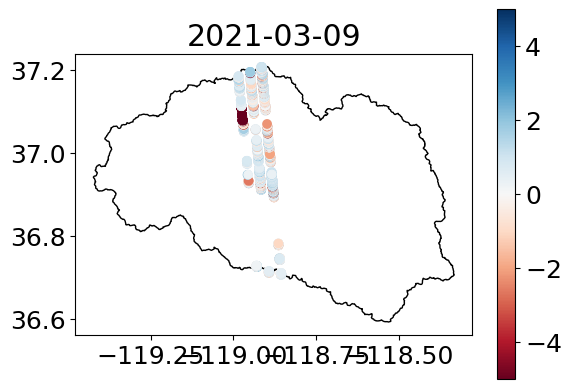

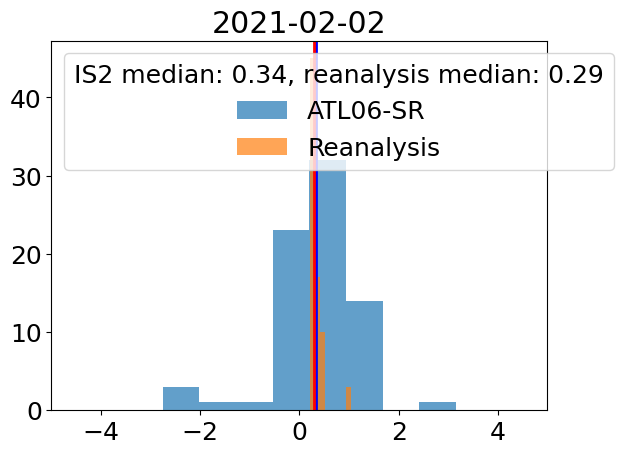

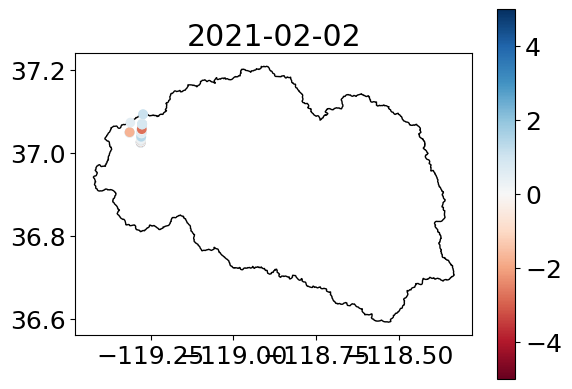

In [249]:
df = atl06sr_gdf.clip(huc8_sierra[huc8_sierra['name'].str.contains('King')].geometry.to_crs(atl06sr_gdf.crs))
snow_column='snow_depth_plus'
acq_dates = list(df['acqdate'].unique())
poly = huc8_sierra[huc8_sierra['name'].str.contains('King')]

for date_index in acq_dates:
    # plot a histogram of the snow-on reanalysis and IS2 data, and display the median values for the basin in the legend title:

    atl06_subset = df.loc[(df['acqdate']==date_index) & (df['reanalysis_fsca']>0.9)][snow_column]
    reanalysis_subset = df.loc[(df['acqdate']==date_index) & (df['reanalysis_fsca']>0.9)]['reanalysis_sd']

    len_atl06_subset = len(atl06_subset[~np.isnan(atl06_subset)])

    if int(np.sqrt(len_atl06_subset)) > 7:
        fig, ax = plt.subplots()
        ax.hist(atl06_subset, bins=int(np.sqrt(len_atl06_subset)), \
                        alpha=0.7, label='ATL06-SR')
        ax.hist(reanalysis_subset, bins=int(np.sqrt(len(reanalysis_subset[~np.isnan(reanalysis_subset)]))), \
                        alpha=0.7, label='Reanalysis')
        ax.axvline(x = np.nanmedian(atl06_subset), linewidth=2, color='blue')
        ax.axvline(x = np.nanmedian(reanalysis_subset), linewidth=2, color='red')
        plt.xlim(-5, 5)
        plt.title(f'{date_index}')
        plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06_subset):.2f}, reanalysis median: {np.nanmedian(reanalysis_subset):.2f}')

        
        # Plot the reanaysis snow depth where fsca > 0.1, and icesat2 data where fsca > 0.1:

        fig, ax = plt.subplots()
        #reanalysis_subset.plot(ax=ax, vmax=2)
        poly.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
        df.loc[(df['acqdate']==date_index) & (df['reanalysis_fsca']>0.9)].to_crs('epsg:4326').plot(column=snow_column,ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
        plt.title(f'{date_index}')
        
    else: continue

### San Joaquin:

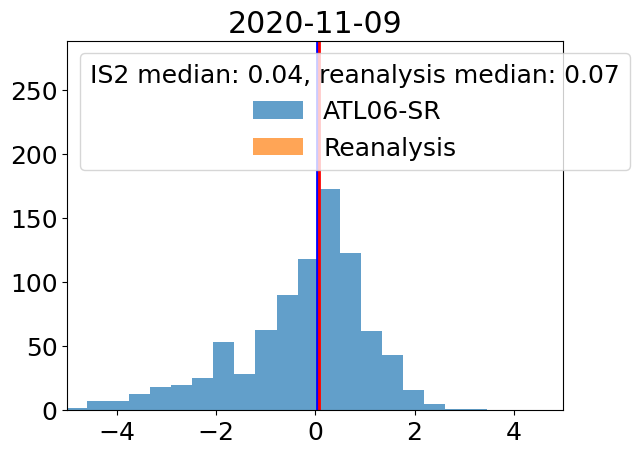

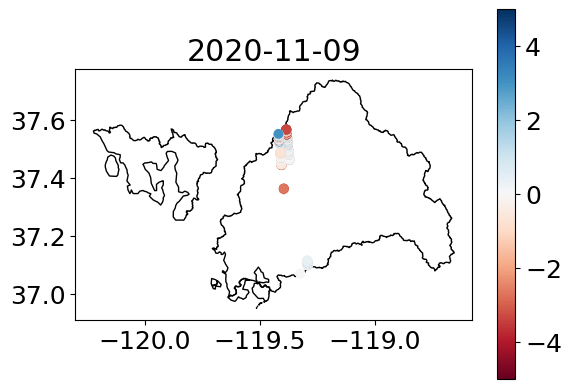

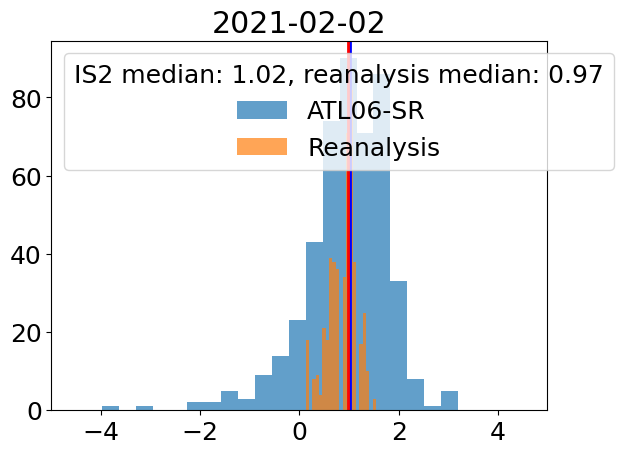

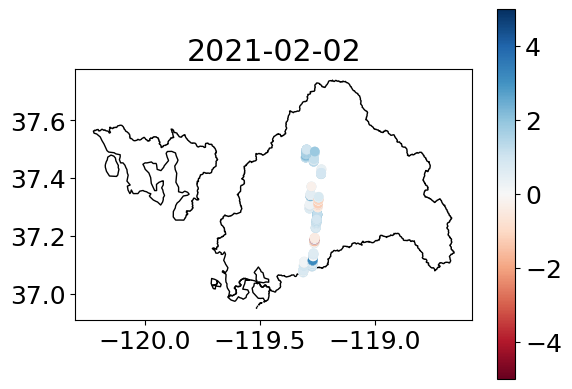

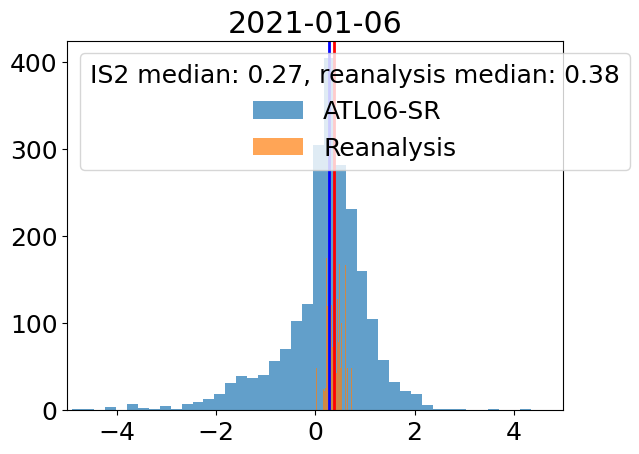

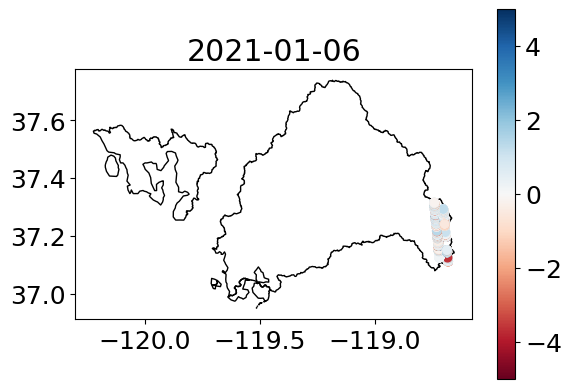

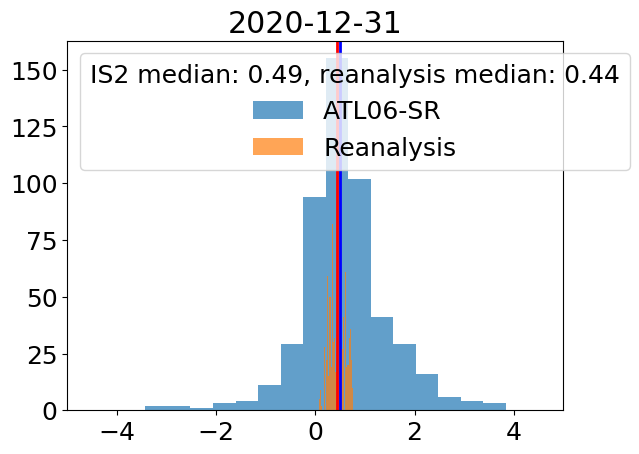

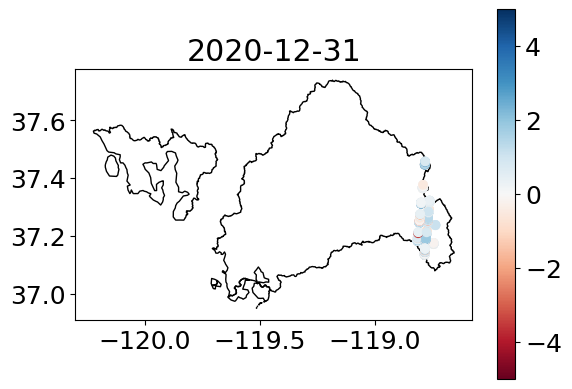

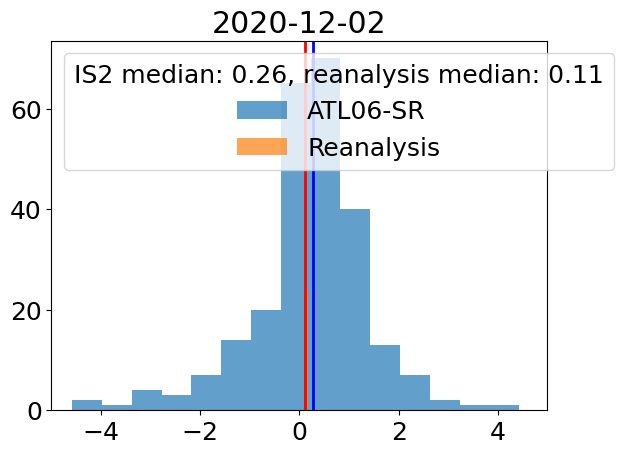

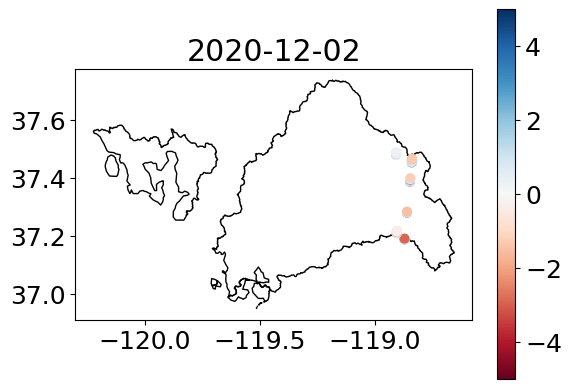

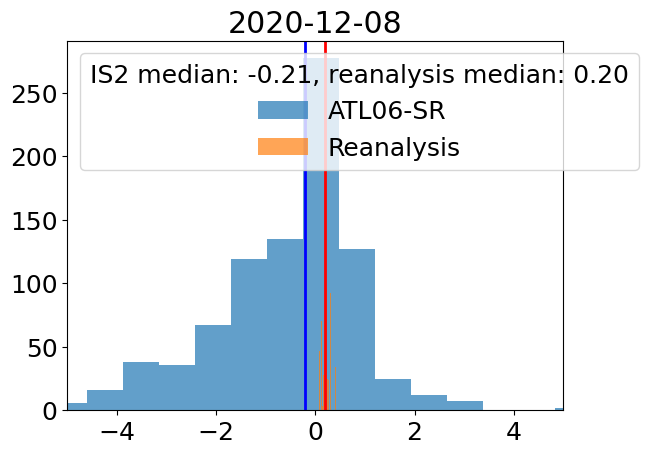

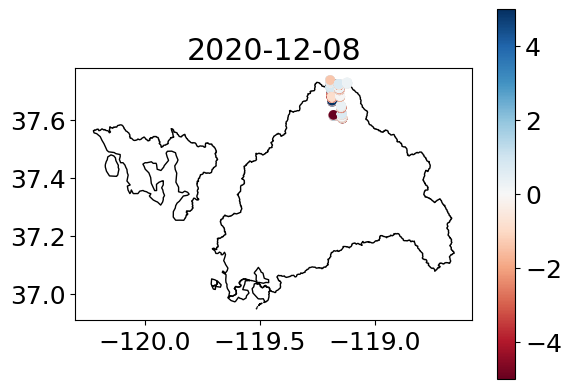

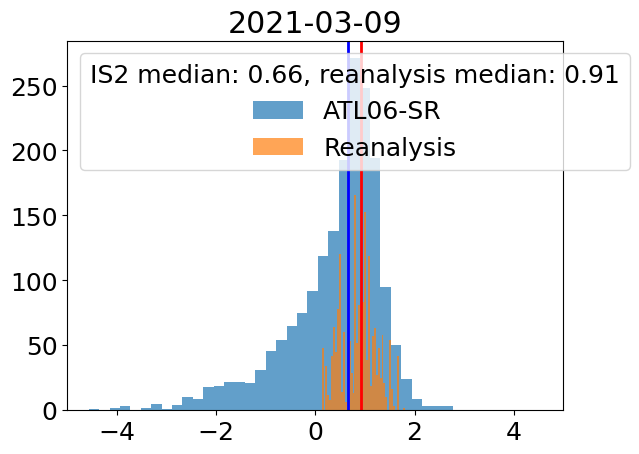

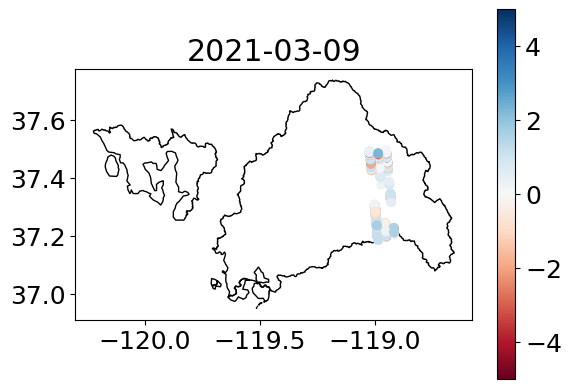

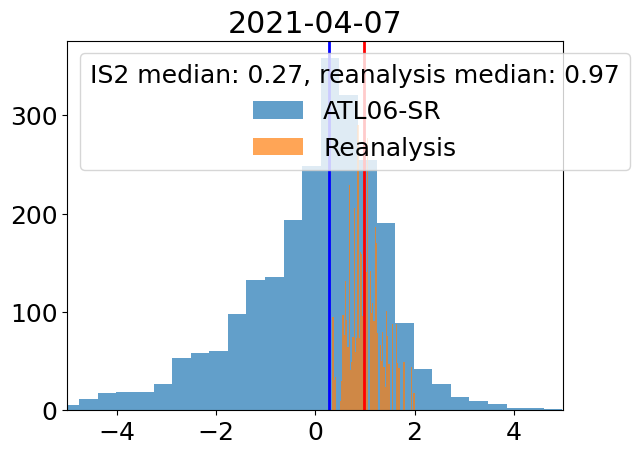

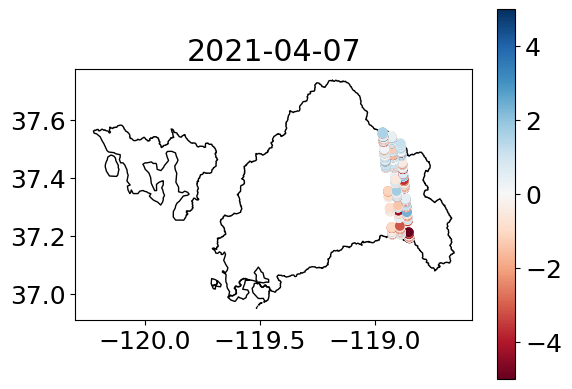

In [250]:
df = atl06sr_gdf.clip(huc8_sierra[huc8_sierra['name'].str.contains('San Joaquin')].geometry.to_crs(atl06sr_gdf.crs))
snow_column='snow_depth_plus'
acq_dates = list(df['acqdate'].unique())
poly = huc8_sierra[huc8_sierra['name'].str.contains('San Joaquin')]

for date_index in acq_dates:
    # plot a histogram of the snow-on reanalysis and IS2 data, and display the median values for the basin in the legend title:

    atl06_subset = df.loc[(df['acqdate']==date_index) & (df['reanalysis_fsca']>0.9)][snow_column]
    reanalysis_subset = df.loc[(df['acqdate']==date_index) & (df['reanalysis_fsca']>0.9)]['reanalysis_sd']

    len_atl06_subset = len(atl06_subset[~np.isnan(atl06_subset)])

    if int(np.sqrt(len_atl06_subset)) > 7:
        fig, ax = plt.subplots()
        ax.hist(atl06_subset, bins=int(np.sqrt(len_atl06_subset)), \
                        alpha=0.7, label='ATL06-SR')
        ax.hist(reanalysis_subset, bins=int(np.sqrt(len(reanalysis_subset[~np.isnan(reanalysis_subset)]))), \
                        alpha=0.7, label='Reanalysis')
        ax.axvline(x = np.nanmedian(atl06_subset), linewidth=2, color='blue')
        ax.axvline(x = np.nanmedian(reanalysis_subset), linewidth=2, color='red')
        plt.xlim(-5, 5)
        plt.title(f'{date_index}')
        plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06_subset):.2f}, reanalysis median: {np.nanmedian(reanalysis_subset):.2f}')

        
        # Plot the reanaysis snow depth where fsca > 0.1, and icesat2 data where fsca > 0.1:

        fig, ax = plt.subplots()
        #reanalysis_subset.plot(ax=ax, vmax=2)
        poly.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
        df.loc[(df['acqdate']==date_index) & (df['reanalysis_fsca']>0.9)].to_crs('epsg:4326').plot(column=snow_column,ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
        plt.title(f'{date_index}')
        
    else: continue

In [190]:
acq_dates_subset = acq_dates[0:2]

for date_index in acq_dates_subset:
    # plot a histogram of the snow-on reanalysis and IS2 data, and display the median values for the basin in the legend title:

    atl06_subset = df.loc[(df['acqdate']==date_index) & (df['reanalysis_fsca']>0.9)][snow_column]
    reanalysis_subset = df.loc[(df['acqdate']==date_index) & (df['reanalysis_fsca']>0.9)]['reanalysis_sd']

    if int(np.sqrt(len(atl06_subset))) > 10:
        fig, ax = plt.subplots()
        ax.hist(atl06_subset, bins=int(np.sqrt(len(atl06_subset))), \
                        alpha=0.7, label='ATL06-SR')
        ax.hist(reanalysis_subset, bins=int(np.sqrt(len(reanalysis_subset))), \
                        alpha=0.7, label='Reanalysis')
        ax.axvline(x = np.nanmedian(atl06_subset), linewidth=2, color='blue')
        ax.axvline(x = np.nanmedian(reanalysis_subset), linewidth=2, color='red')
        plt.xlim(-5, 5)
        plt.title(f'{acq_dates[date_index]}')
        plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06_subset):.2f}, reanalysis median: {np.nanmedian(reanalysis_subset):.2f}')

        
        # Plot the reanaysis snow depth where fsca > 0.1, and icesat2 data where fsca > 0.1:

        fig, ax = plt.subplots()
        #reanalysis_subset.plot(ax=ax, vmax=2)
        poly.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
        df.loc[(df['acqdate']==date_index)].to_crs('epsg:4326').plot(column=snow_column,ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
        plt.title(f'{date_index}')
        
    else: continue

In [185]:
plot_reanalysis_dif(atl06sr_american, 'snow_depth_plus', huc8_sierra[huc8_sierra['name'].str.contains('American')])

In [ ]:
date_index = 0

# Subset the reanalysis snow depth and fsca data by the IS2 acquisition date:

reanalysis_test = reanalysis_clipped_2019[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]
reanalysis_fsca = fsca_reanalysis_clipped_2019[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

# plot a histogram of the snow-on reanalysis and IS2 data, and display the median values for the basin in the legend title:

fig, ax = plt.subplots()
ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic'],\
            bins=250, alpha=0.7, label='ATL06-SR')
ax.hist(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten(),\
            bins=250, alpha=0.7, label='Reanalysis')
ax.axvline(x = np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']), linewidth=2, color='blue')
ax.axvline(x = np.nanmedian(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten()), linewidth=2, color='red')
plt.xlim(-5, 5)
plt.title(f'{snowon_dates[date_index]}')
plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']):.2f}, reanalysis median: {np.nanmedian(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten()):.2f}')

# Plot the reanaysis snow depth where fsca > 0.1, and icesat2 data where fsca > 0.1:

fig, ax = plt.subplots()
reanalysis_test.where(reanalysis_fsca>0.1).plot(ax=ax, vmax=2)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
plt.title(f'{snowon_dates[date_index]}')

In [148]:
atl06sr_american['acqdate'].unique()

array([datetime.date(2021, 9, 14), datetime.date(2021, 3, 17),
       datetime.date(2021, 10, 12), datetime.date(2020, 11, 13),
       datetime.date(2021, 7, 14), datetime.date(2021, 8, 11),
       datetime.date(2020, 11, 11), datetime.date(2021, 4, 13),
       datetime.date(2021, 4, 15), datetime.date(2021, 5, 12),
       datetime.date(2021, 3, 11)], dtype=object)

In [149]:
huc10_sierra[huc10_sierra['name'].str.contains('Feather')]

,tnmid,metasource,sourcedata,sourceorig,sourcefeat,loaddate,referenceg,areaacres,areasqkm,states,huc10,name,hutype,humod,shape_Leng,shape_Area,ObjectID,geometry
146,{77CD01A6-8296-44B0-B32C-0F896C33038E},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-15,223423,47295.36,191.40,CA,1802015902,Upper Feather River,S,None,NaN,NaN,768,"POLYGON ((-121.52069 39.59876, -121.52081 39.5..."
192,{F8A8CD90-59FB-4728-A3CD-37B0A76ABCCB},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-15,267458,100575.15,407.01,CA,1802012306,South Fork Feather River,S,None,NaN,NaN,833,"POLYGON ((-120.87941 39.78725, -120.87863 39.7..."
193,{03A9A4C3-3040-4428-BED2-E0C5BDA05A40},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-15,263528,155671.65,629.98,CA,1802012307,Lower Middle Fork Feather River,S,None,NaN,NaN,529,"MULTIPOLYGON (((-121.26302 39.85644, -121.2622..."
194,{12A3398E-B387-4A38-9BCE-6B3D642FB637},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-15,264163,79255.20,320.73,CA,1802012108,Lower North Fork Feather River,S,None,NaN,NaN,542,"MULTIPOLYGON (((-121.45314 39.81806, -121.4527..."
195,{DF48F8E6-98FA-4923-8257-E3319F9F2DEF},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-15,268869,107271.42,434.11,CA,1802012107,West Branch Feather River,S,None,NaN,NaN,575,"MULTIPOLYGON (((-121.43995 40.09325, -121.4392..."
196,{E6F42CC1-04A2-49D7-9B01-52D4AC741607},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-15,264163,133103.94,538.65,CA,1802012106,Middle North Fork Feather River,S,None,NaN,NaN,400,"POLYGON ((-121.31974 40.05764, -121.31931 40.0..."
198,{C13B6EFE-32C2-4763-99DF-D25491302B9D},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-15,266674,48947.35,198.08,CA,1802012209,East Branch North Fork Feather River,S,None,NaN,NaN,182,"POLYGON ((-121.0309 40.13278, -121.02982 40.13..."
204,{50FACE42-3B73-4201-B81A-56073F214F0A},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-15,263528,151508.10,613.13,CA,1802012304,Upper Middle Fork Feather River,S,None,NaN,NaN,584,"POLYGON ((-120.59397 39.96165, -120.59293 39.9..."
205,{BA2BEAB0-9E60-43C5-9355-928AF28DE5D6},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-15,263528,130759.11,529.16,CA,1802012305,Middle Middle Fork Feather River,S,None,NaN,NaN,808,"POLYGON ((-120.68033 39.92166, -120.67978 39.9..."
219,{EF81ABAE-3CA7-4F06-84A6-4A563A1A9FD1},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-15,264163,157387.95,636.93,CA,1802012104,Upper North Fork Feather River,S,None,NaN,NaN,352,"MULTIPOLYGON (((-121.08936 40.28819, -121.0886..."


In [157]:
huc10_sierra[huc10_sierra['name'].str.contains('Tuolumne')]

,tnmid,metasource,sourcedata,sourceorig,sourcefeat,loaddate,referenceg,areaacres,areasqkm,states,huc10,name,hutype,humod,shape_Leng,shape_Area,ObjectID,geometry
110,{18A91BF2-F0D8-4C53-90F0-D9A869652C1D},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-15,255171,46733.84,189.13,CA,1804000906,Middle Tuolumne River,S,NM,NaN,NaN,524,"POLYGON ((-119.74807 37.9346, -119.74753 37.93..."
111,{A5662066-ACCE-4142-8935-EA2D0A5BEC5F},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-15,255171,136808.96,553.65,CA,1804000901,Headwaters Tuolumne River,S,NM,NaN,NaN,424,"POLYGON ((-119.37625 38.09402, -119.37597 38.0..."
114,{F470A198-5CF4-4F9A-812D-48420DE0AAA7},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-15,"260042,255171",123894.68,501.38,CA,1804000905,Falls Creek-Tuolumne River,S,RS,NaN,NaN,126,"POLYGON ((-119.58861 38.18564, -119.58793 38.1..."
119,{A6BD119A-6E56-4F9A-A8E2-9D514A49C833},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-15,"228884,255171",107276.50,434.13,CA,1804000912,Moccasin Creek-Tuolumne River,S,"RS,PD,RC,WD",NaN,NaN,934,"POLYGON ((-120.26794 37.94785, -120.26813 37.9..."
120,{36460FD2-1E6E-4A2E-949E-E2CE8133CB9E},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-15,267514,57798.29,233.90,CA,1804000907,South Fork Tuolumne River,S,NM,NaN,NaN,324,"POLYGON ((-119.79182 37.85723, -119.79174 37.8..."
121,{CF149095-04F6-444E-8BF4-006113334484},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-15,"219171,255171",81519.88,329.90,CA,1804000910,Big Creek-Tuolumne River,S,NM,NaN,NaN,171,"MULTIPOLYGON (((-120.20593 38.05473, -120.2056..."
125,{97F9111B-3206-4590-8F71-E2585E51DA90},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-15,234378,63866.68,258.46,CA,1804000909,North Fork Tuolumne River,S,NM,NaN,NaN,157,"POLYGON ((-119.99069 38.18694, -119.99004 38.1..."


<Axes: >

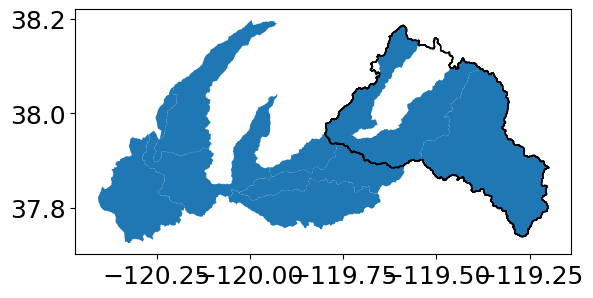

In [162]:
fig, ax = plt.subplots()
huc10_sierra[huc10_sierra['name'].str.contains('Tuolumne')].plot(ax=ax)
tuol.plot(ax=ax, facecolor='none')
#sierras.plot(ax=ax, facecolor='none', edgecolor='r')

<Axes: >

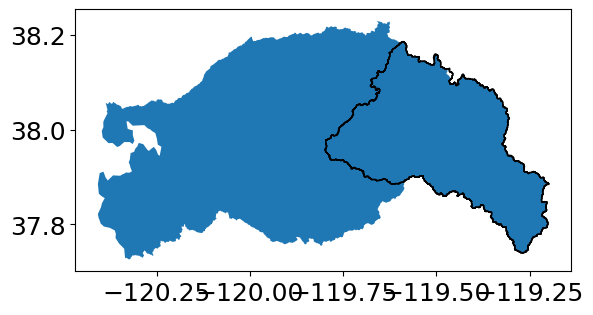

In [166]:
fig, ax = plt.subplots()
huc8_sierra[huc8_sierra['name'].str.contains('Tuolumne')].plot(ax=ax)
tuol.plot(ax=ax, facecolor='none')